# Define Helper Functions

In [9]:
import pandas as pd
import os
from functools import reduce
import numpy as np
from collections import defaultdict
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    make_scorer
)
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import datetime
import json

# This function loads multiple feature files and merges them into one big table.
# Each file contains measurements for different participants, conditions, and time windows.
def load_and_merge_features(file_list, feature_dir='data'):
    base_keys = ['participant', 'condition', 'window_index', 'phase']
    dfs = []

    for fname, phase in file_list:
        full = os.path.join(feature_dir, fname)
        df   = pd.read_csv(full)
        df['phase'] = phase  # Mark which phase (e.g., baseline or experimental) this data is from

        # Make sure the file has the required columns
        if not all(k in df.columns for k in ['participant', 'condition', 'window_index']):
            raise ValueError(f"{fname} missing required keys")

        # If the file is in a "long" format (RQA-style), reshape it to "wide" format
        if 'column' in df.columns:
            id_vars = ['participant', 'condition', 'window_index', 'phase', 'column']
            value_vars = [col for col in df.columns if col not in id_vars + ['window_start', 'window_end']]
            df_long = df.melt(id_vars=id_vars, value_vars=value_vars,
                              var_name='metric', value_name='value')

            df_pivot = df_long.pivot_table(
                index=['participant', 'condition', 'window_index', 'phase'],
                columns=['column', 'metric'],
                values='value'
            )

            # Rename columns to make them easier to use
            df_pivot.columns = [f"{col1}__{col2}" for col1, col2 in df_pivot.columns]
            df = df_pivot.reset_index()
        else:
            # Remove unnecessary columns
            if 'window_start' in df.columns:
                df = df.drop(columns=['window_start'])

            prefix = os.path.splitext(os.path.basename(fname))[0]
            skip = base_keys + ['window_start']
            feats = [c for c in df.columns if c not in skip]
            # Rename columns to include the file name as a prefix
            df.rename(columns={c: f"{prefix}__{c}" for c in feats}, inplace=True)

        dfs.append(df)

    # Merge all dataframes together, matching on participant, condition, window, and phase
    merged = reduce(lambda L, R: pd.merge(L, R, on=base_keys, how='outer'), dfs)
    return merged.fillna(0)  # Fill missing values with zero

# This function randomly splits the data into training and testing sets.
# Used to check how well the model works on unseen data.
def split_random_windows(df, test_size=0.2, random_state=42):
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )
    return train_df, test_df

# This function splits the data so that some participants are used for training, and others for testing.
def split_by_participants(df, test_size=0.2, random_state=42, participant_col='participant'):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, groups=df[participant_col]))
    return df.iloc[train_idx], df.iloc[test_idx]

# This function creates incremental splits for baseline vs experimental phases.
# It helps test how adding more experimental data affects model performance.
def split_baseline_experimental_incremental(
        df, 
        phase_col='phase',
        baseline_phase='baseline',
        experimental_phase='experimental',
        window_col='window_index'
):
    base_df = df[df[phase_col]==baseline_phase]
    exp_df = df[df[phase_col]==experimental_phase]

    uniq = sorted(exp_df[window_col].unique())[::2]
    splits = []
    for k in range(len(uniq)+1):
        use=set(uniq[:k])
        train = pd.concat([
            base_df,
            exp_df[exp_df[window_col].isin(use)]
        ], ignore_index=True)
        test = exp_df[~exp_df[window_col].isin(use)].reset_index(drop=True)
        splits.append((train, test, k))
    return splits

# This function selects the best features (measurements) to use for prediction.
# It tries adding or removing groups of features and checks which combination works best.
def select_features(
        df,
        feature_cols,
        label_col='condition',
        method='forward',
        level='group',
        stopping='drop',
        verbose=True
    ):
        def get_groups(cols):
            # Get the list of feature groups (e.g., all metrics for a signal)
            return sorted({c.split('__')[0] for c in cols}) if level == 'group' else sorted(cols)

        def get_group_columns(group, cols):
            # Get all columns belonging to a group
            return [c for c in cols if c.startswith(group + '__')] if level == 'group' else [group]

        def evaluate_feature_set(cols):
            # Train a model and check its accuracy using cross-validation
            X, y = df[cols], df[label_col]
            rf = RandomForestClassifier(random_state=42)
            cv = StratifiedKFold(5, shuffle=True, random_state=42)
            scores = cross_validate(rf, X, y, cv=cv,
                                    scoring={'bal_acc': 'balanced_accuracy'})
            return np.mean(scores['test_bal_acc'])

        available = get_groups(feature_cols)
        best_score = -np.inf
        current = available.copy() if method == 'backward' else []
        history = []
        improving = True

        if verbose:
            print(f"\n=== Feature selection: {method} on {level}s ===")

        # Try adding/removing groups and keep track of the best combination
        while improving and available:
            candidates = []
            for g in available:
                trial = (current + [g]) if method == 'forward' else [x for x in current if x != g]
                cols = [f for grp in trial for f in get_group_columns(grp, feature_cols)]
                score = evaluate_feature_set(cols)
                candidates.append((score, g, trial))

            candidates.sort(reverse=True, key=lambda x: x[0])
            top_score, top_grp, top_trial = candidates[0]
            history.append((top_score, top_trial.copy()))

            if method == 'forward':
                if top_score > best_score:
                    best_score, current = top_score, top_trial
                    available.remove(top_grp)
                else:
                    improving = False if stopping == 'drop' else available.remove(top_grp)
            else:
                if top_score >= best_score:
                    best_score, current = top_score, top_trial
                    available.remove(top_grp)
                else:
                    improving = False if stopping == 'drop' else available.remove(top_grp)

        if stopping == 'best':
            best_score, current = max(history, key=lambda x: x[0])

        selected_features = [f for grp in current for f in get_group_columns(grp, feature_cols)]
        
        if verbose:
            print(f"✔ Selected {len(current)} {level}(s): {current}")
        return selected_features

# This function trains a Random Forest model to classify workload conditions.
# It can use different strategies for splitting data, select features, and show plots.
def train_random_forest(
    df,
    split_strategy='random',
    test_size=0.2,
    train_duration_sec=6*60,
    n_seeds=10,
    label_col='condition',
    use_pca=False,
    pca_variance=0.95,
    feature_selection=None,
    selection_level='group',
    selection_stopping='drop',
    show_plots=False,
    output_dir=None
):
    df = df.copy()
    id_cols = ['participant', 'condition', 'window_index']
    all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in all_numeric if c not in id_cols]

    classes = sorted(df[label_col].unique())
    n_classes = len(classes)

    def get_groups(cols):
        if selection_level == 'group':
            return sorted({c.split('__')[0] for c in cols})
        return sorted(cols)

    def get_group_columns(group, cols):
        if selection_level == 'group':
            return [c for c in cols if c.startswith(group + '__')]
        return [group]

    def evaluate_feature_set(cols):
        X, y = df[cols], df[label_col]
        rf = RandomForestClassifier(random_state=42)
        cv = StratifiedKFold(5, shuffle=True, random_state=42)
        scores = cross_validate(rf, X, y, cv=cv,
                                 scoring={'bal_acc': 'balanced_accuracy'})
        return np.mean(scores['test_bal_acc'])

    # If feature selection is requested, run it first
    if feature_selection in ('forward','backward'):
        print(f"\n=== Running {feature_selection} selection on {selection_level}s ===")
        available = get_groups(feature_cols)
        best_score = -np.inf
        current = available.copy() if feature_selection=='backward' else []
        history = []
        improving = True

        while improving and available:
            candidates = []
            for g in tqdm(available, desc=f"{feature_selection.title()} Selection", leave=False):
                trial = (current + [g]) if feature_selection=='forward' else [x for x in current if x!=g]
                cols = [feat for grp in trial for feat in get_group_columns(grp, feature_cols)]
                score = evaluate_feature_set(cols)
                candidates.append((score, g, trial))
            candidates.sort(reverse=True, key=lambda x:x[0])
            top_score, top_grp, top_trial = candidates[0]
            history.append((top_score, top_trial.copy()))

            if feature_selection=='forward':
                if top_score>best_score:
                    best_score, current = top_score, top_trial
                    available.remove(top_grp)
                else:
                    if selection_stopping=='drop': improving=False
                    else: available.remove(top_grp)
            else:
                if top_score>=best_score:
                    best_score, current = top_score, top_trial
                    available.remove(top_grp)
                else:
                    if selection_stopping=='drop': improving=False
                    else: available.remove(top_grp)

        if selection_stopping=='best':
            best_score, current = max(history, key=lambda x:x[0])

        print(f"Selected {len(current)} {selection_level}(s): {current}")
        feature_cols = [f for grp in current for f in get_group_columns(grp, feature_cols)]

    # Main training loop: repeat with different random seeds for reliability
    metrics = defaultdict(list)
    cm_sum  = np.zeros((n_classes, n_classes))
    imp_acc = defaultdict(list)

    is_single_group = (
        selection_level == 'group' and
        len({f.split('__')[0] for f in feature_cols}) == 1 and
        not use_pca
    )

    for seed in range(n_seeds):
        # Split the data into training and testing sets
        adapt = None
        if split_strategy == 'random':
            tr, te = split_random_windows(df, test_size, seed)
        elif split_strategy == 'participant':
            tr, te = split_by_participants(df, test_size, seed)
        elif split_strategy == 'fewshot':
            # now returns (train_df, test_df, adapt_df)
            tr, te, adapt = split_fewshot(
                df,
                participant_col='participant',
                phase_col='phase',
                test_size=test_size,
                random_state=seed
            )
        elif split_strategy == 'pre_main':          
            tr, te = split_pre_vs_main(df, phase_col='phase')
        else:
            tr, te = split_temporal(df, train_duration_sec)

        X_tr, y_tr = tr[feature_cols], tr[label_col]
        X_te, y_te = te[feature_cols], te[label_col]

        # Train the Random Forest model
        rf = RandomForestClassifier(random_state=seed)
        rf.fit(X_tr, y_tr)

        # If using "fewshot" strategy, calibrate the model with a small adaptation set
        if split_strategy == 'fewshot' and adapt is not None and not adapt.empty:
            from sklearn.calibration import CalibratedClassifierCV
            calibrator = CalibratedClassifierCV(rf, method='isotonic', cv='prefit')
            X_adapt = adapt[feature_cols]
            y_adapt = adapt[label_col]
            calibrator.fit(X_adapt, y_adapt)
            y_pred = calibrator.predict(X_te)
        else:
            y_pred = rf.predict(X_te)

        # Optionally, reduce features using PCA (Principal Component Analysis)
        if use_pca:
            parts_tr, parts_te = [], []
            for grp in get_groups(feature_cols):
                cols = get_group_columns(grp, feature_cols)
                scaler = StandardScaler()
                Xt = scaler.fit_transform(X_tr[cols])
                Xe = scaler.transform(X_te[cols])
                p = PCA(pca_variance, svd_solver='full', random_state=seed)
                Xt_p = p.fit_transform(Xt)
                Xe_p = p.transform(Xe)
                names = [f"{grp}_pc{i}" for i in range(p.n_components_)]
                parts_tr.append(pd.DataFrame(Xt_p, columns=names, index=X_tr.index))
                parts_te.append(pd.DataFrame(Xe_p, columns=names, index=X_te.index))
            X_tr = pd.concat(parts_tr, axis=1)
            X_te = pd.concat(parts_te, axis=1)

        # Cross-validate the model and collect performance metrics
        rf = RandomForestClassifier(random_state=seed)
        cv = StratifiedKFold(5, shuffle=True, random_state=seed)
        cv_res = cross_validate(rf, X_tr, y_tr, cv=cv,
                                scoring={
                                  'acc':'accuracy',
                                  'bal_acc':'balanced_accuracy',
                                  'f1':'f1_macro',
                                  'kappa':make_scorer(cohen_kappa_score)
                                })
        metrics['cv_acc'].append(cv_res['test_acc'].mean())
        metrics['cv_bal_acc'].append(cv_res['test_bal_acc'].mean())
        metrics['cv_f1'].append(cv_res['test_f1'].mean())
        metrics['cv_kappa'].append(cv_res['test_kappa'].mean())

        # Train and test the model on the split data
        rf.fit(X_tr, y_tr)
        y_pred = rf.predict(X_te)
        metrics['test_acc'].append(accuracy_score(y_te,y_pred))
        metrics['test_bal_acc'].append(balanced_accuracy_score(y_te,y_pred))
        metrics['test_f1'].append(f1_score(y_te,y_pred,average='macro'))
        metrics['test_kappa'].append(cohen_kappa_score(y_te,y_pred))

        cm_sum += confusion_matrix(y_te, y_pred, labels=classes)

        # Collect feature importances (which measurements matter most for prediction)
        for feat, imp in zip(X_te.columns, rf.feature_importances_):
            if selection_level=='metric' and not use_pca:
                imp_acc[feat].append(imp)
            elif is_single_group:
                imp_acc[feat].append(imp)
            else:
                grp = feat.split('_pc')[0] if use_pca else feat.split('__')[0]
                imp_acc[grp].append(imp)

    def _mean(x): return float(np.mean(x))
    def _std(x):  return float(np.std(x, ddof=1))   

    # Print summary of model performance
    print("\n=== CV Metrics ===")
    for k in ['cv_acc','cv_bal_acc','cv_f1','cv_kappa']:
        print(f"{k}: {np.mean(metrics[k]):.3f}")
    print("\n=== Test Metrics ===")
    for k in ['test_acc','test_bal_acc','test_f1','test_kappa']:
        print(f"{k}: {np.mean(metrics[k]):.3f}")

    metrics_mean = {f"{k}_mean": _mean(v) for k, v in metrics.items()}
    metrics_std  = {f"{k}_std":  _std(v)  for k, v in metrics.items()}  

    results = {
    'metrics':   {**metrics_mean, **metrics_std},
    'cm_sum':    cm_sum,
    'imp_acc':   dict(imp_acc),
    'classes':   classes,
    'feature_cols': feature_cols
    }

    # Package results for saving or further analysis
    # results = {
    #     'metrics':   {k: np.mean(v) for k, v in metrics.items()},
    #     'cm_sum':    cm_sum,
    #     'imp_acc':   dict(imp_acc),
    #     'classes':   classes,
    #     'feature_cols': feature_cols
    # }
    if output_dir:
    # If user passed a path ending in .json, treat it as the full filename
        if output_dir.endswith(".json"):
            os.makedirs(os.path.dirname(output_dir), exist_ok=True)
            save_path = output_dir
        else:
            os.makedirs(output_dir, exist_ok=True)
            save_path = os.path.join(output_dir, "results.json")

        with open(save_path, "w") as f:
            def convert(obj):
                if isinstance(obj, np.ndarray):
                    return obj.tolist()
                if isinstance(obj, np.generic):
                    return obj.item()
                return obj
            json.dump({k: convert(v) for k, v in results.items()}, f, indent=2)

        print(f"Saved results to {save_path}")


    # Optionally, show plots of model results
    if show_plots:
        # Plot confusion matrix (shows how well the model distinguishes between classes)
        cm_prop = cm_sum / cm_sum.sum(axis=1, keepdims=True)
        annot   = np.array([[f"{v:.1f}%" for v in row*100] for row in cm_prop])
        plt.figure(figsize=(6,5))
        sns.heatmap(cm_prop*100, annot=annot, fmt='s',
                    xticklabels=classes, yticklabels=classes,
                    vmin=0, vmax=100, cmap='Blues')
        plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

        # Plot feature importances (which measurements matter most)
        metric_mode = (selection_level=='metric' and not use_pca)
        if metric_mode:
            avg_imp = {feat: np.mean(imp_acc[feat])
                       for feat in feature_cols if feat in imp_acc}
            labels, imps = zip(*sorted(avg_imp.items(), key=lambda x: x[1], reverse=True))
            title = "Feature Importances (Individual Metrics)"
        else:
            grp_imp = defaultdict(list)
            for key, imps in imp_acc.items():
                grp_imp[key].extend(imps)
            avg_imp = {g: np.mean(v) for g,v in grp_imp.items()}
            labels, imps = zip(*sorted(avg_imp.items(), key=lambda x: x[1], reverse=True))
            title = "Feature Group Importances"

        plt.figure(figsize=(8,5))
        sns.barplot(x=list(imps), y=list(labels))
        plt.xlabel("Mean Importance")
        plt.title(title)
        plt.tight_layout()
        if output_dir:
            fig_path = os.path.join(output_dir, 'confusion_matrix.png')  # or 'feature_importance.png'
            plt.savefig(fig_path)
            print(f"Saved plot to {fig_path}")
        else:
            plt.show()

    return results

# This function logs the model results to a CSV file for record-keeping.
# It avoids logging duplicate entries.
def log_rf_results_to_csv(
    metrics_dict,
    feature_groups_used,
    config,
    selected_items=None,
    log_path="model_eval_log.csv"
):
    """
    Logs the results from train_random_forest to a CSV file if not already logged.

    If feature elimination was used, `selected_items` should be a list of
    groups or metric names actually retained.
    """
    # Create a key for the feature groups used
    feature_key = "+".join(sorted(feature_groups_used))
    
    # Build the row to log
    row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "feature_groups": feature_key,
        "split_strategy": config.get("split_strategy"),
        "feature_selection": config.get("feature_selection"),
        "selection_level": config.get("selection_level"),
        "selection_stopping": config.get("selection_stopping"),
        "pca_used": config.get("use_pca"),
        "pca_variance": config.get("pca_variance"),
        "n_seeds": config.get("n_seeds"),
        # If feature elimination was used, record the actual selected items
        "selected_items": "+".join(sorted(selected_items)) if selected_items else ""
    }
    # Add metrics to the row
    row.update(metrics_dict)

    # Read or create the log file
    if os.path.exists(log_path):
        log_df = pd.read_csv(log_path)
        # Check for duplicate entries
        duplicate_check = (
            (log_df['feature_groups'] == feature_key)
            & (log_df['split_strategy'] == row['split_strategy'])
            & (log_df['pca_used'] == row['pca_used'])
            & (log_df['feature_selection'] == row['feature_selection'])
        )
        if duplicate_check.any():
            print(f"[LOG] Skipping duplicate entry: {feature_key}, PCA={row['pca_used']}, "
                  f"Split={row['split_strategy']}, Selection={row['feature_selection']}")
            return
        log_df = pd.concat([log_df, pd.DataFrame([row])], ignore_index=True)
    else:
        log_df = pd.DataFrame([row])

    # Save the log to CSV
    log_df.to_csv(log_path, index=False)
    print(f"[LOG] Logged new entry: {feature_key}, PCA={row['pca_used']}, "
          f"Split={row['split_strategy']}, Selection={row['feature_selection']}")

# File paths

In [3]:
# assumes all of these csvs are under data/
feature_groups = {
    "linear_pose_pre": [
        ("linear_pose_metrics/baseline_pose_metrics.csv", "pre")
    ],
    "performance_pre": [
        ("performance/performance_bsl.csv", "pre")
    ],
    "performance_main": [
        ("performance/performance_exp.csv", "main")
    ],
    "linear_pose_main": [
        ("linear_pose_metrics/experimental_pose_metrics.csv", "main")
    ],
    "rqa_pose_pre": [
        ("rqa/baseline_pose_rqa.csv", "pre")
    ],
    "rqa_pose_main": [
        ("rqa/experimental_pose_rqa.csv", "main")
    ]
}

selected_group = feature_groups["linear_pose_main"] #+ feature_groups["rqa_pose_main"] # merge different files together
merged_df = load_and_merge_features(selected_group)
print(merged_df.shape) # make sure it looks appropriate 
print(merged_df.columns[:10])

(3192, 34)
Index(['experimental_pose_metrics__file', 'participant', 'condition',
       'window_index', 'experimental_pose_metrics__window_start_s',
       'experimental_pose_metrics__window_end_s',
       'experimental_pose_metrics__center_face_magnitude_mean_abs_vel',
       'experimental_pose_metrics__center_face_magnitude_mean_abs_acc',
       'experimental_pose_metrics__center_face_magnitude_rms',
       'experimental_pose_metrics__avg_pupil_magnitude_mean_abs_vel'],
      dtype='object')


# 4.3.1 Verification of Load Manipulations

In [9]:
selected_group = feature_groups["performance_main"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='random', 
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=20,
    show_plots=False,
    output_dir='data/model_output/4_3_1_random.json'
)


=== Running forward selection on metrics ===


Selected 3 metric(s): ['performance_exp__track_point_accuracy', 'performance_exp__mean_comms_response_time', 'performance_exp__resman_point_accuracy']

=== CV Metrics ===
cv_acc: 0.534
cv_bal_acc: 0.533
cv_f1: 0.523
cv_kappa: 0.300

=== Test Metrics ===
test_acc: 0.543
test_bal_acc: 0.543
test_f1: 0.532
test_kappa: 0.314
Saved results to data/model_output/4_3_1_random.json


In [11]:
selected_group = feature_groups["performance_main"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='participant', 
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=20,
    show_plots=False,
    output_dir='data/model_output/4_3_1_participant.json'
)


=== Running forward selection on metrics ===


Selected 3 metric(s): ['performance_exp__track_point_accuracy', 'performance_exp__mean_comms_response_time', 'performance_exp__resman_point_accuracy']

=== CV Metrics ===
cv_acc: 0.547
cv_bal_acc: 0.546
cv_f1: 0.537
cv_kappa: 0.320

=== Test Metrics ===
test_acc: 0.493
test_bal_acc: 0.492
test_f1: 0.480
test_kappa: 0.239
Saved results to data/model_output/4_3_1_participant.json


# 4.3.2 Linear Pose Features as Load Classifiers


=== Running forward selection on metrics ===


Selected 13 metric(s): ['experimental_pose_metrics__head_rotation_angle_mean_abs_acc', 'experimental_pose_metrics__mouth_dist_mean_abs_vel', 'experimental_pose_metrics__avg_pupil_x_mean_abs_vel', 'experimental_pose_metrics__center_face_y_mean_abs_vel', 'experimental_pose_metrics__center_face_magnitude_mean_abs_acc', 'experimental_pose_metrics__avg_pupil_magnitude_mean_abs_acc', 'experimental_pose_metrics__blink_dist_mean_abs_vel', 'experimental_pose_metrics__avg_pupil_y_mean_abs_vel', 'experimental_pose_metrics__head_rotation_angle_mean_abs_vel', 'experimental_pose_metrics__center_face_x_mean_abs_acc', 'experimental_pose_metrics__center_face_y_mean_abs_acc', 'experimental_pose_metrics__blink_dist_rms', 'experimental_pose_metrics__avg_pupil_magnitude_mean_abs_vel']

=== CV Metrics ===
cv_acc: 0.843
cv_bal_acc: 0.843
cv_f1: 0.843
cv_kappa: 0.765

=== Test Metrics ===
test_acc: 0.866
test_bal_acc: 0.866
test_f1: 0.866
test_kappa: 0.799
Saved results to data/model_output/4_3_2_random.json


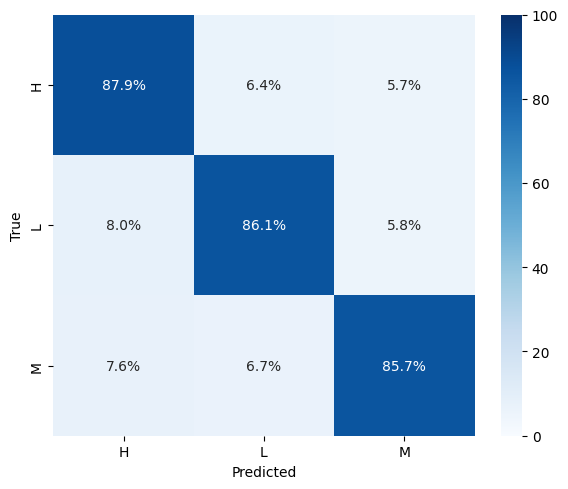

NotADirectoryError: [Errno 20] Not a directory: '/Users/cartersale/Documents/Research/Manuscripts/MATB_Nature/data/model_output/4_3_2_random.json/confusion_matrix.png'

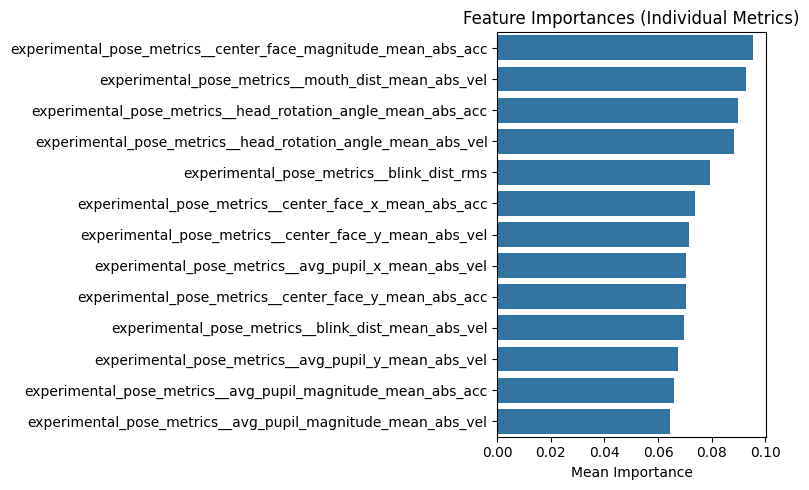

In [4]:
selected_group = feature_groups["linear_pose_main"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='random', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=20,
    show_plots=True,
    output_dir='data/model_output/4_3_2_random.json'
)

In [5]:
selected_group = feature_groups["linear_pose_main"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='participant', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=20,
    show_plots=False,
    output_dir='data/model_output/4_3_2_participant.json')


=== Running forward selection on metrics ===


Selected 13 metric(s): ['experimental_pose_metrics__head_rotation_angle_mean_abs_acc', 'experimental_pose_metrics__mouth_dist_mean_abs_vel', 'experimental_pose_metrics__avg_pupil_x_mean_abs_vel', 'experimental_pose_metrics__center_face_y_mean_abs_vel', 'experimental_pose_metrics__center_face_magnitude_mean_abs_acc', 'experimental_pose_metrics__avg_pupil_magnitude_mean_abs_acc', 'experimental_pose_metrics__blink_dist_mean_abs_vel', 'experimental_pose_metrics__avg_pupil_y_mean_abs_vel', 'experimental_pose_metrics__head_rotation_angle_mean_abs_vel', 'experimental_pose_metrics__center_face_x_mean_abs_acc', 'experimental_pose_metrics__center_face_y_mean_abs_acc', 'experimental_pose_metrics__blink_dist_rms', 'experimental_pose_metrics__avg_pupil_magnitude_mean_abs_vel']

=== CV Metrics ===
cv_acc: 0.876
cv_bal_acc: 0.876
cv_f1: 0.876
cv_kappa: 0.814

=== Test Metrics ===
test_acc: 0.415
test_bal_acc: 0.415
test_f1: 0.412
test_kappa: 0.122
Saved results to data/model_output/4_3_2_participant.

## figs

Saved confusion matrix for 4_3_1_participant to figs/cm/cm_4_3_1_participant.svg


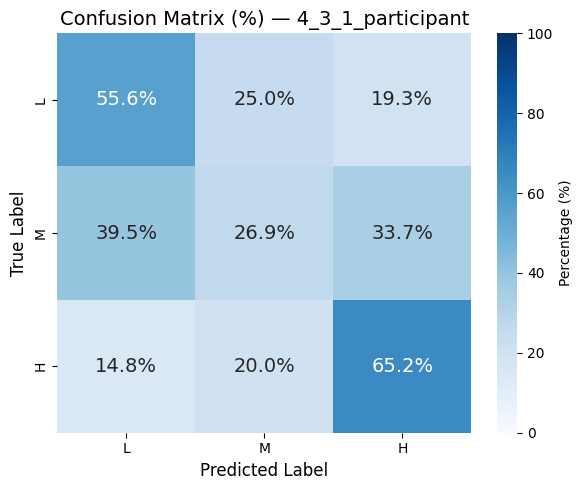

Saved confusion matrix for 4_3_3_random_rqa_linear to figs/cm/cm_4_3_3_random_rqa_linear.svg


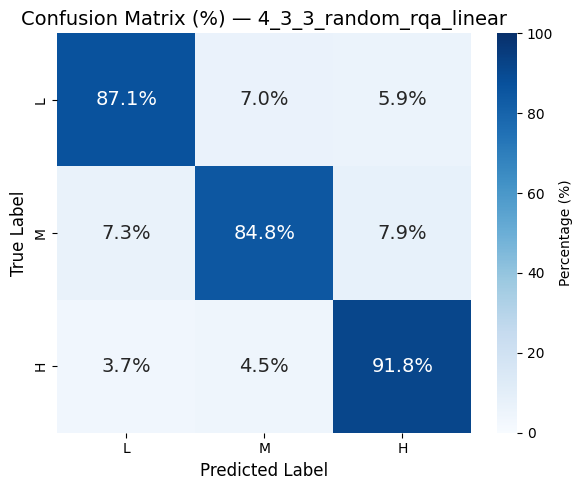

Saved confusion matrix for 4_3_2_random to figs/cm/cm_4_3_2_random.svg


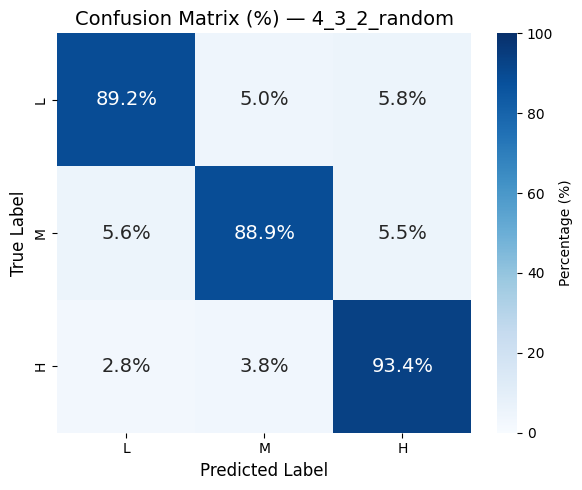

Saved confusion matrix for 4_3_3_participant_rqa_linear to figs/cm/cm_4_3_3_participant_rqa_linear.svg


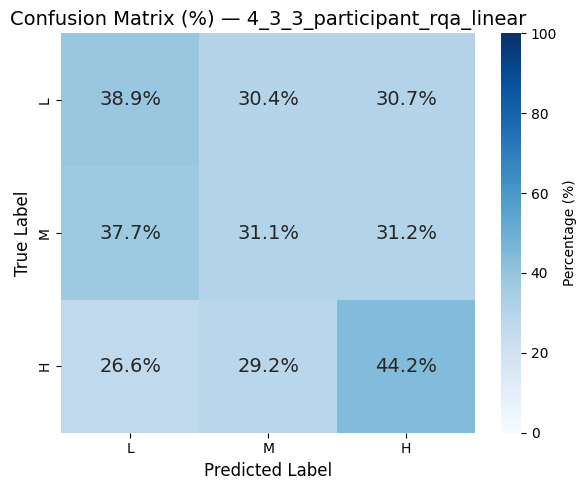

Saved confusion matrix for 4_3_1_random to figs/cm/cm_4_3_1_random.svg


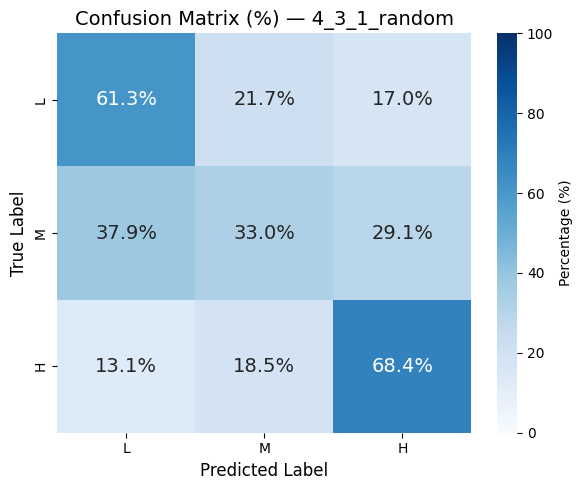

Saved confusion matrix for 4_3_3_random_rqa_alone to figs/cm/cm_4_3_3_random_rqa_alone.svg


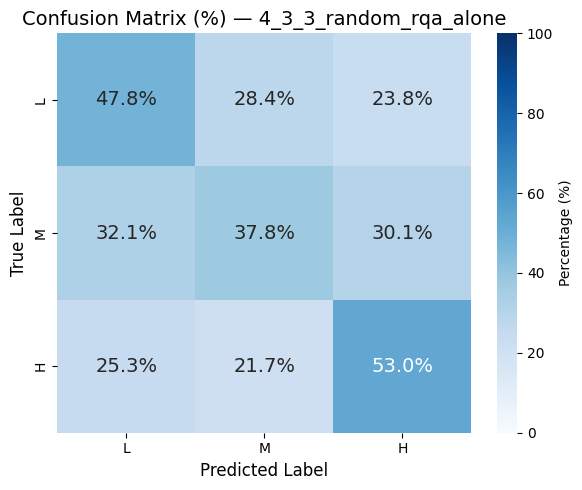

Saved confusion matrix for 4_3_2_participant to figs/cm/cm_4_3_2_participant.svg


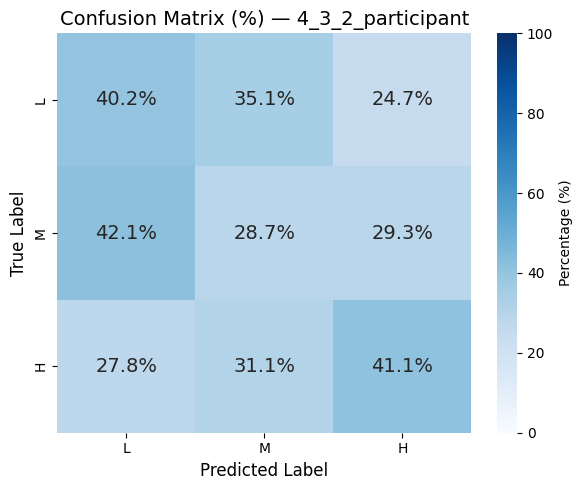

Saved confusion matrix for 4_3_3_participant_rqa_alone to figs/cm/cm_4_3_3_participant_rqa_alone.svg


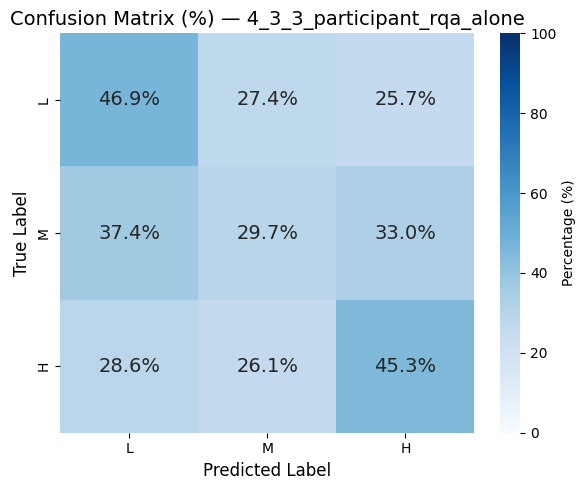

In [39]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Directory where your JSON files live
json_dir = "data/model_output"
json_pattern = os.path.join(json_dir, "*.json")

# Make output directory for confusion matrix figures
out_dir = "figs/cm"
os.makedirs(out_dir, exist_ok=True)

# Find all JSON files
json_files = glob.glob(json_pattern)

for json_path in json_files:
    # Load JSON
    with open(json_path, "r") as f:
        data = json.load(f)

    # Extract confusion matrix and class labels
    cm_raw = np.array(data["cm_sum"])
    labels = data.get("classes", None)

    # Normalize by row to get percentages
    cm = cm_raw.astype(np.float64)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_percent = np.divide(cm, row_sums, where=row_sums != 0) * 100
    desired_order = ["L", "M", "H"]
    if labels:
        indices = [labels.index(l) for l in desired_order if l in labels]
        cm_percent = cm_percent[indices][:, indices]
        labels = [labels[i] for i in indices]

    # Format with % signs
    annotations = np.array([["{:.1f}%".format(v) for v in row] for row in cm_percent])

    # Create figure
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm_percent,
        annot=annotations,
        fmt="",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        vmin=0,
        vmax=100,
        annot_kws={"size": 14},  # ← controls font size of the percentages
        cbar_kws={"label": "Percentage (%)"}
    )


    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    base = os.path.splitext(os.path.basename(json_path))[0]
    ax.set_title(f"Confusion Matrix (%) — {base}", fontsize=14)

    plt.tight_layout()
    out_path = os.path.join(out_dir, f"cm_{base}.svg")
    plt.savefig(out_path, dpi=300)
    print(f"Saved confusion matrix for {base} to {out_path}")
    plt.show()


# 4.3.3 Nonlinear Feature Comparison

In [29]:
selected_group = feature_groups["rqa_pose_main"] #+ feature_groups["linear_pose_main"]
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='random', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=20,
    show_plots=False,
    output_dir='data/model_output/4_3_3_random_rqa_only.json')


=== Running forward selection on metrics ===


Selected 7 metric(s): ['center_face_magnitude__vmax', 'avg_pupil_y__maxl_found', 'crqa_head_eye_x__vmax', 'avg_pupil_y__mean_line_length', 'center_face_y__vmax', 'blink_dist__perc_recur', 'center_face_y__divergence']

=== CV Metrics ===
cv_acc: 0.463
cv_bal_acc: 0.462
cv_f1: 0.460
cv_kappa: 0.194

=== Test Metrics ===
test_acc: 0.462
test_bal_acc: 0.462
test_f1: 0.460
test_kappa: 0.193
Saved results to data/model_output/4_3_3_random_rqa_only.json


## figs

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

# File paths per (Feature Set, Validation Strategy)
model_files = {
    ("Linear", "Cross-Task"): "data/model_output/4_3_2_random.json",
    ("Linear", "Cross-Participant"): "data/model_output/4_3_2_participant.json",
    ("Nonlinear", "Cross-Task"): "data/model_output/4_3_3_random_rqa_alone.json",
    ("Nonlinear", "Cross-Participant"): "data/model_output/4_3_3_participant_rqa_alone.json",
    ("Combined", "Cross-Task"): "data/model_output/4_3_3_random_rqa_linear.json",
    ("Combined", "Cross-Participant"): "data/model_output/4_3_3_participant_rqa_linear.json"
}

feature_sets = ["Linear", "Nonlinear", "Combined"]

def load_mean_std(path):
    with open(path, "r") as f:
        data = json.load(f)
    m = data.get("metrics", {})
    # New format: *_mean / *_std ; Old format: plain test_bal_acc
    if "test_bal_acc_mean" in m:
        mean = m["test_bal_acc_mean"] * 100.0
        std  = (m.get("test_bal_acc_std") or 0.0) * 100.0
    else:
        mean = m["test_bal_acc"] * 100.0
        std  = 0.0  # no std available in old logs
    return mean, std

# Collect means/stdevs
ct_means, ct_stds = [], []
cp_means, cp_stds = [], []
for fs in feature_sets:
    ct_mean, ct_std = load_mean_std(model_files[(fs, "Cross-Task")])
    cp_mean, cp_std = load_mean_std(model_files[(fs, "Cross-Participant")])
    ct_means.append(ct_mean); ct_stds.append(ct_std)
    cp_means.append(cp_mean); cp_stds.append(cp_std)

# === Plotting ===
x = np.arange(len(feature_sets))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width/2, ct_means, width,
    label='Cross-Task',
    yerr=ct_stds, capsize=4, linewidth=1.2, edgecolor='black'
)
bars2 = ax.bar(
    x + width/2, cp_means, width,
    label='Cross-Participant',
    yerr=cp_stds, capsize=4,
    hatch='//', edgecolor='black', facecolor='none', linewidth=1.5
)

# Annotate bars with mean ± std (omit ±0.0)
def fmt(mu, sd):
    return f"{mu:.1f}%"

for container, means, stds in [(bars1, ct_means, ct_stds), (bars2, cp_means, cp_stds)]:
    for bar, mu, sd in zip(container, means, stds):
        ax.annotate(
            fmt(mu, sd),
            xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
            xytext=(0, 3), textcoords="offset points",
            ha='center', va='bottom', fontsize=9
        )

ax.set_ylabel('Balanced Accuracy (%)')
ax.set_xlabel('Input Features')
ax.set_xticks(x); ax.set_xticklabels(feature_sets)
ax.set_ylim(0, 100)
ax.legend(title='Validation')

plt.tight_layout()
os.makedirs("figs", exist_ok=True)
plt.savefig("figs/linear_nl_model_comparison.svg")
plt.show()

In [30]:
import os, json, glob

DIR = "data/model_output"

def pct(x):
    return f"{x*100:.1f}%" if isinstance(x, (int, float)) else "NA"

def sd(x):
    return f"{x*100:.1f}" if isinstance(x, (int, float)) else "NA"

def fmt_float(x, digits=3):
    if isinstance(x, (int, float)):
        return f"{x:.{digits}f}"
    return "NA"

for path in sorted(glob.glob(os.path.join(DIR, "*.json"))):
    try:
        with open(path, "r") as f:
            data = json.load(f)
        m = data.get("metrics", data)

        acc_mean = m.get("test_acc_mean")
        acc_std  = m.get("test_acc_std")
        f1_mean  = m.get("test_f1_mean")
        f1_std   = m.get("test_f1_std")
        kap_mean = m.get("test_kappa_mean")
        kap_std  = m.get("test_kappa_std")
        bal_mean = m.get("test_bal_acc_mean")
        bal_std  = m.get("test_bal_acc_std")

        kap_str = fmt_float(kap_mean, 3)
        if isinstance(kap_std, (int, float)):
            kap_str += f" ± {fmt_float(kap_std, 3)}"

        print(
            f"{os.path.basename(path):<40} "
            f"Acc {pct(acc_mean)} ± {sd(acc_std)} | "
            f"BalAcc {pct(bal_mean)} ± {sd(bal_std)} | "
            f"F1 {pct(f1_mean)} ± {sd(f1_std)} | "
            f"κ {kap_str}"
        )
    except Exception as e:
        print(f"{os.path.basename(path):<40} ERROR: {e}")


4_3_1_participant.json                   Acc 49.3% ± 1.7 | BalAcc 49.2% ± 1.7 | F1 48.0% ± 1.8 | κ 0.239 ± 0.025
4_3_1_random.json                        Acc 54.3% ± 2.0 | BalAcc 54.3% ± 1.9 | F1 53.2% ± 2.0 | κ 0.314 ± 0.030
4_3_2_participant.json                   Acc 36.7% ± 4.8 | BalAcc 36.6% ± 4.8 | F1 36.3% ± 4.9 | κ 0.050 ± 0.071
4_3_2_random.json                        Acc 90.5% ± 1.4 | BalAcc 90.5% ± 1.4 | F1 90.5% ± 1.4 | κ 0.857 ± 0.020
4_3_3_participant_rqa_linear.json        Acc 38.1% ± 3.4 | BalAcc 38.1% ± 3.4 | F1 37.7% ± 3.5 | κ 0.071 ± 0.051
4_3_3_participant_rqa_only.json          Acc 40.7% ± 1.2 | BalAcc 40.6% ± 1.3 | F1 40.1% ± 1.3 | κ 0.110 ± 0.019
4_3_3_random_rqa_linear.json             Acc 87.9% ± 1.4 | BalAcc 87.9% ± 1.4 | F1 87.8% ± 1.4 | κ 0.818 ± 0.021
4_3_3_random_rqa_only.json               Acc 46.2% ± 1.7 | BalAcc 46.2% ± 1.7 | F1 46.0% ± 1.7 | κ 0.193 ± 0.026


# 4.3.4 Baseline Features

In [ ]:
selected_group = feature_groups["linear_pose_main"] + feature_groups["linear_pose_pre"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='participant', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=False,
    output_dir='data/model_output')

In [ ]:
selected_group = feature_groups["linear_pose_main"] + feature_groups["performance_pre"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='participant', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=False,
    output_dir='data/model_output')

In [ ]:
selected_group = feature_groups["linear_pose_main"] + feature_groups["linear_pose_pre"] + feature_groups["performance_pre"]
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='participant', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=False,
    output_dir='data/model_output')

In [ ]:
selected_group = feature_groups["linear_pose_main"] + feature_groups["linear_pose_pre"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='participant', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=False,
    output_dir='data/model_output')

In [ ]:
import json
import matplotlib.pyplot as plt

# === Step 1: Labels ===
conditions = ["Exp Pose", "+Bsl Perf", "+Bsl Pose", "+Both"]

# Hardcoded file paths for each validation scheme
windows_files = [
    "data/model_output/4_3_2_random.json",
    "data/model_output/4_3_4_random_linear_main_pre_perf.json",
    "data/model_output/4_3_4_random_linear_main_pre_pose.json",
    "data/model_output/4_3_4_random_linear_main_pre_pose_perf.json"
]

lop_files = [
    "data/model_output/4_3_2_participant.json",
    "data/model_output/4_3_4_participant_linear_main_pre_perf.json",
    "data/model_output/4_3_4_participant_linear_main_pre_pose.json",
    "data/model_output/4_3_4_participant_linear_main_pre_pose_perf.json"
]

# === Step 2: Load accuracy values ===
def extract_accuracy(file_list, key):
    accs = []
    for file in file_list:
        with open(file, 'r') as f:
            data = json.load(f)
            accs.append(data["metrics"][key] * 100)
    return accs

windows_acc = extract_accuracy(windows_files, "test_bal_acc")
lop_acc = extract_accuracy(lop_files, "test_bal_acc")

# === Step 3: Plotting ===
plt.figure(figsize=(8, 5))

plt.plot(conditions, windows_acc, marker='o', color='royalblue', label="Cross-Task")
plt.plot(conditions, lop_acc, marker='o', color='firebrick', label="Cross-Participant")

# Add annotations
for i, (w_acc, l_acc) in enumerate(zip(windows_acc, lop_acc)):
    plt.text(i, w_acc + 1, f"{w_acc:.1f}%", ha='center', va='bottom', fontsize=9)
    plt.text(i, l_acc - 3, f"{l_acc:.1f}%", ha='center', va='top', fontsize=9)

# Aesthetic
plt.ylim(0, 100)
plt.ylabel("% Balanced Accuracy")
plt.title("Effect of Baseline Metrics")
plt.legend(title="Validation")
plt.savefig("figs/baseline_model_results")
plt.tight_layout()
plt.show()


# Batch Runs

In [ ]:
# ========= BATCH RUN HARNESS =========
import itertools
import os
from datetime import datetime
from tqdm import tqdm

# 1) Define experiment grid (feature groups + configs)
#    Use any keys from your `feature_groups` dict.
EXPERIMENTS = [
    # Single group examples
    {"groups": ["linear_pose_main"]},
    {"groups": ["rqa_pose_main"]},
    {"groups": ["performance_main"]},

    # Merged groups (concatenate file lists)
    {"groups": ["linear_pose_main", "rqa_pose_main"]},
]

# Model config grid
SPLIT_STRATEGIES   = ["random", "participant"]  
FEATURE_SELECTIONS = ["forward"]
SELECTION_LEVELS   = ["metric"]
SELECTION_STOPPING = ["drop"]           # stop when no improvement vs pick best across history
USE_PCA            = [False]                    # set to [False, True] if you want to try PCA too
PCA_VARIANCE       = 0.95
N_SEEDS            = 20

# 2) Helper to build merged file list from group keys
def _files_for_groups(group_keys):
    files = []
    for g in group_keys:
        if g not in feature_groups:
            raise KeyError(f"Unknown feature group: {g}")
        files += feature_groups[g]
    return files

# 3) Run one experiment/config and persist artifacts
def run_one_experiment(group_keys, cfg, base_outdir="data/model_output"):
    # Make a readable run id
    gtag = "+".join(group_keys)
    ctag = [
        f"split={cfg['split_strategy']}",
        f"sel={cfg['feature_selection'] or 'none'}",
        f"lvl={cfg['selection_level']}",
        f"stop={cfg['selection_stopping']}",
        f"pca={cfg['use_pca']}",
        f"var={cfg['pca_variance']}",
        f"seeds={cfg['n_seeds']}",
    ]
    run_id = "__".join([gtag] + ctag).replace("/", "-")

    # Output paths
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = os.path.join(base_outdir, ts, run_id)
    os.makedirs(run_dir, exist_ok=True)
    json_path = os.path.join(run_dir, "results.json")

    # Merge features for these groups
    files = _files_for_groups(group_keys)
    merged = load_and_merge_features(files)

    # Train & save per-run JSON (train_random_forest already saves if output_dir is *.json)
    res = train_random_forest(
        merged,
        split_strategy=cfg["split_strategy"],
        test_size=cfg.get("test_size", 0.2),
        n_seeds=cfg["n_seeds"],
        label_col=cfg.get("label_col", "condition"),
        use_pca=cfg["use_pca"],
        pca_variance=cfg["pca_variance"],
        feature_selection=cfg["feature_selection"],
        selection_level=cfg["selection_level"],
        selection_stopping=cfg["selection_stopping"],
        show_plots=False,                           # turn off for batch
        output_dir=json_path                        # ensures a JSON per run
    )

    # Log to your CSV
    # NOTE: `res['feature_cols']` are the actual columns used after selection/PCA decisions.
    log_cfg = {
        "split_strategy": cfg["split_strategy"],
        "feature_selection": cfg["feature_selection"],
        "selection_level": cfg["selection_level"],
        "selection_stopping": cfg["selection_stopping"],
        "use_pca": cfg["use_pca"],
        "pca_variance": cfg["pca_variance"],
        "n_seeds": cfg["n_seeds"],
    }
    # Flatten metric means/stds to a single row via your logger
    log_rf_results_to_csv(
        metrics_dict=res["metrics"],
        feature_groups_used=group_keys,
        config=log_cfg,
        selected_items=res.get("feature_cols", []),
        log_path=os.path.join(base_outdir, "batch_summary.csv"),
    )

    return {"run_dir": run_dir, "json": json_path, "metrics": res["metrics"]}

# 4) Build the full config grid (filters to legal combos)
def _config_product():
    for split, sel, lvl, stop, pca in itertools.product(
        SPLIT_STRATEGIES, FEATURE_SELECTIONS, SELECTION_LEVELS, SELECTION_STOPPING, USE_PCA
    ):
        # If no selection, level/stop don't matter; normalize to defaults
        if sel is None:
            lvl  = "group"
            stop = "drop"
        yield {
            "split_strategy": split,
            "feature_selection": sel,
            "selection_level": lvl,
            "selection_stopping": stop,
            "use_pca": pca,
            "pca_variance": PCA_VARIANCE,
            "n_seeds": N_SEEDS,
        }

# 5) Master batch loop
def run_batch(experiments=EXPERIMENTS, outdir="data/model_output"):
    summaries = []
    total = len(experiments) * sum(1 for _ in _config_product())
    for exp in tqdm(experiments, desc="Experiments"):
        group_keys = exp["groups"]
        for cfg in tqdm(list(_config_product()), desc="Configs", leave=False):
            try:
                out = run_one_experiment(group_keys, cfg, base_outdir=outdir)
                summaries.append({
                    "groups": "+".join(group_keys),
                    **cfg,
                    **out["metrics"],
                    "run_dir": out["run_dir"],
                    "json_path": out["json"],
                })
                print(f"[OK] {out['run_dir']}")
            except Exception as e:
                print(f"[FAIL] groups={group_keys} cfg={cfg} -> {e}")

    # also keep a one-shot CSV across all runs in this batch
    if summaries:
        df = pd.DataFrame(summaries)
        os.makedirs(outdir, exist_ok=True)
        # timestamped batch summary to avoid overwrite
        batch_csv = os.path.join(outdir, f"batch_runs_{datetime.now().strftime('%Y%m%d-%H%M%S')}.csv")
        df.to_csv(batch_csv, index=False)
        print(f"[BATCH] Wrote {len(df)} rows to {batch_csv}")

# 6) Fire it

run_batch()


In [1]:
import os, glob
import pandas as pd
from pathlib import Path

BASE_OUT = "data/model_output"

def _latest_batch_csv(base=BASE_OUT):
    files = sorted(glob.glob(os.path.join(base, "batch_runs_*.csv")), key=os.path.getmtime)
    if not files:
        raise FileNotFoundError(f"No batch_runs_*.csv in {base}")
    return files[-1]

def _fmt_mu_sigma(mu, sd, digs=3):
    if pd.isna(mu): return "--"
    if pd.isna(sd): return f"{mu:.{digs}f}"
    return f"{mu:.{digs}f} ± {sd:.{digs}f}"

def build_split_tables(batch_csv=None, out_dir=BASE_OUT, digits=3):
    batch_csv = batch_csv or _latest_batch_csv(out_dir)
    df = pd.read_csv(batch_csv)

    # Minimal display identifier for each run
    df["experiment"] = (
        df["groups"] + " | sel=" + df["feature_selection"].fillna("none")
        + " lvl=" + df["selection_level"]
        + " stop=" + df["selection_stopping"]
        + " pca=" + df["use_pca"].astype(str)
    )

    # Columns we care about (these keys come from train_random_forest -> results['metrics'])
    need = [
        "experiment", "split_strategy", "n_seeds",
        "test_acc_mean", "test_acc_std",
        "test_f1_mean", "test_f1_std",
        "test_kappa_mean", "test_kappa_std",
    ]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise KeyError(f"Batch CSV missing expected columns: {missing}")

    os.makedirs(out_dir, exist_ok=True)

    for split in df["split_strategy"].dropna().unique():
        sub = df.loc[df["split_strategy"] == split, need].copy()

        # Pretty columns with mean ± std
        sub["Accuracy"] = [
            _fmt_mu_sigma(mu, sd, digits) for mu, sd in zip(sub["test_acc_mean"], sub["test_acc_std"])
        ]
        sub["F1 (macro)"] = [
            _fmt_mu_sigma(mu, sd, digits) for mu, sd in zip(sub["test_f1_mean"], sub["test_f1_std"])
        ]
        sub["Cohen's κ"] = [
            _fmt_mu_sigma(mu, sd, digits) for mu, sd in zip(sub["test_kappa_mean"], sub["test_kappa_std"])
        ]

        table = sub[["experiment", "Accuracy", "F1 (macro)", "Cohen's κ", "n_seeds"]].copy()
        table = table.sort_values(by=["experiment"]).reset_index(drop=True)

        # Build LaTeX
        lines = [
            r"\begin{tabular}{lccc r}",
            r"\toprule",
            rf"\multicolumn{{5}}{{l}}{{\textbf{{Results — split: {split}}}}} \\",
            r"\midrule",
            r"Run (groups | cfg) & Accuracy & F1 (macro) & Cohen's $\kappa$ & seeds \\",
            r"\midrule",
        ]
        for _, r in table.iterrows():
            lines.append(f"{r['experiment']} & {r['Accuracy']} & {r['F1 (macro)']} & {r['Cohen\'s κ']} & {int(r['n_seeds'])} \\\\")
        lines += [r"\bottomrule", r"\end{tabular}"]

        out_tex = Path(out_dir) / f"metrics_table_{split}.tex"
        out_tex.write_text("\n".join(lines), encoding="utf-8")
        print(f"[OK] wrote {out_tex} ({len(table)} rows)")

# run it
build_split_tables()


[OK] wrote data/model_output/metrics_table_random.tex (4 rows)
[OK] wrote data/model_output/metrics_table_participant.tex (4 rows)


In [3]:
import os, glob, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_OUT = "data/model_output"
FIG_DIR  = Path("figs/figure_4_confusion_matrix")
FIG_DIR.mkdir(parents=True, exist_ok=True)

COND_ORDER = ["L", "M", "H"]

def _latest_batch_csv(base=BASE_OUT):
    files = sorted(glob.glob(os.path.join(base, "batch_runs_*.csv")), key=os.path.getmtime)
    if not files:
        raise FileNotFoundError(f"No batch_runs_*.csv in {base}")
    return files[-1]

def _safe(s: str) -> str:
    return "".join(c if c.isalnum() or c in "-_+." else "_" for c in s)

def plot_confusion_from_json(json_path: str, title: str, out_svg: Path):
    with open(json_path, "r") as f:
        res = json.load(f)

    cm = np.array(res["cm_sum"], dtype=float)
    classes = list(res["classes"])

    # --- Force L, M, H ordering ---
    # Build a mapping from class -> index in cm
    idx_map = {cls: i for i, cls in enumerate(classes)}
    keep = [idx_map[c] for c in COND_ORDER if c in idx_map]

    # Reorder both axes
    cm = cm[np.ix_(keep, keep)]
    classes = [c for c in COND_ORDER if c in idx_map]

    # row-normalize to percentages
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    cm_pct = (cm / row_sums) * 100.0

    annot = np.array([[f"{v:.1f}%" for v in row] for row in cm_pct])

    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(
        cm_pct,
        annot=annot,
        fmt="s",
        cmap="Blues",
        vmin=0,
        vmax=100,
        xticklabels=classes,
        yticklabels=classes,
        cbar_kws={"label": "% of true class"}
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_svg, dpi=300, format="svg")
    plt.close()
    print(f"[OK] saved {out_svg}")

# ---- drive it over the latest batch csv ----
batch_csv = _latest_batch_csv(BASE_OUT)
df = pd.read_csv(batch_csv)

df["run_id"] = df["run_dir"].apply(lambda p: Path(str(p)).name if isinstance(p, str) else "run")

for _, row in df.iterrows():
    split = row.get("split_strategy", "unknown")
    run_id = row["run_id"]
    json_path = row.get("json_path")
    if not isinstance(json_path, str) or not os.path.exists(json_path):
        print(f"[SKIP] JSON missing: {json_path}")
        continue

    title = f"Confusion Matrix — split={split} — {row.get('groups','')}"
    out_svg = FIG_DIR / f"cm__{_safe(split)}__{_safe(run_id)}.svg"
    try:
        plot_confusion_from_json(json_path, title, out_svg)
    except Exception as e:
        print(f"[FAIL] {json_path}: {e}")


[OK] saved figs/figure_4_confusion_matrix/cm__random__linear_pose_main__split_random__sel_forward__lvl_metric__stop_drop__pca_False__var_0.95__seeds_20.svg
[OK] saved figs/figure_4_confusion_matrix/cm__participant__linear_pose_main__split_participant__sel_forward__lvl_metric__stop_drop__pca_False__var_0.95__seeds_20.svg
[OK] saved figs/figure_4_confusion_matrix/cm__random__rqa_pose_main__split_random__sel_forward__lvl_metric__stop_drop__pca_False__var_0.95__seeds_20.svg
[OK] saved figs/figure_4_confusion_matrix/cm__participant__rqa_pose_main__split_participant__sel_forward__lvl_metric__stop_drop__pca_False__var_0.95__seeds_20.svg
[OK] saved figs/figure_4_confusion_matrix/cm__random__performance_main__split_random__sel_forward__lvl_metric__stop_drop__pca_False__var_0.95__seeds_20.svg
[OK] saved figs/figure_4_confusion_matrix/cm__participant__performance_main__split_participant__sel_forward__lvl_metric__stop_drop__pca_False__var_0.95__seeds_20.svg
[OK] saved figs/figure_4_confusion_matri

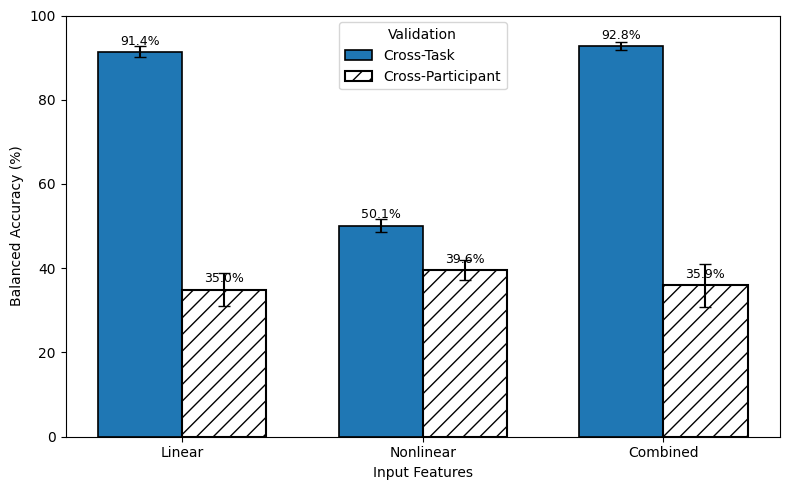

[OK] saved figs/figure_5_model_acc_learning_curves/linear_nl_model_comparison.svg


In [5]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_OUT = "data/model_output"
FIG_PATH = "figs/figure_5_model_acc_learning_curves/linear_nl_model_comparison.svg"

FEATURE_SETS = ["Linear", "Nonlinear", "Combined"]
SPLIT_LABELS = {"random": "Cross-Task", "participant": "Cross-Participant"}

# canonical mapping from feature set -> groups (order-agnostic)
TARGET_GROUPS = {
    "Linear": {"linear_pose_main"},
    "Nonlinear": {"rqa_pose_main"},
    "Combined": {"linear_pose_main", "rqa_pose_main"},
}

# find latest batch_runs_*.csv
batch_files = sorted(glob.glob(os.path.join(BASE_OUT, "batch_runs_*.csv")), key=os.path.getmtime)
if not batch_files:
    raise FileNotFoundError(f"No batch_runs_*.csv in {BASE_OUT}")
batch_csv = batch_files[-1]

df = pd.read_csv(batch_csv)

# normalize groups to set-of-strings (order-agnostic)
def groups_to_set(s):
    if not isinstance(s, str): return set()
    return set([g.strip() for g in s.split("+") if g.strip()])

df["_groups_set"] = df["groups"].apply(groups_to_set)

# filter to your intended config (matches your grid)
want = (
    (df["feature_selection"] == "forward") &
    (df["selection_level"] == "metric") &
    (df["selection_stopping"] == "drop") &
    (df["use_pca"] == False)
)
dfw = df.loc[want].copy()

# helper to select the row for (feature_set, split). If duplicates, take best mean.
def pick_row(feature_set, split):
    target = TARGET_GROUPS[feature_set]
    sub = dfw.loc[(dfw["split_strategy"] == split) & (dfw["_groups_set"] == target)]
    if sub.empty:
        raise ValueError(f"No run for feature_set={feature_set}, split={split}")
    # if multiple (shouldn't, but just in case), take best balanced acc
    sub = sub.sort_values("test_bal_acc_mean", ascending=False)
    return sub.iloc[0]

def get_mu_sd(row):
    mu = float(row.get("test_bal_acc_mean", np.nan)) * 100.0
    sd = float(row.get("test_bal_acc_std", 0.0)) * 100.0
    return mu, sd

# collect means/stds
ct_means, ct_stds = [], []
cp_means, cp_stds = [], []
for fs in FEATURE_SETS:
    r_ct = pick_row(fs, "random")
    r_cp = pick_row(fs, "participant")
    mu_ct, sd_ct = get_mu_sd(r_ct)
    mu_cp, sd_cp = get_mu_sd(r_cp)
    ct_means.append(mu_ct); ct_stds.append(sd_ct)
    cp_means.append(mu_cp); cp_stds.append(sd_cp)

# === Plotting ===
x = np.arange(len(FEATURE_SETS))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width/2, ct_means, width,
    label=SPLIT_LABELS["random"],
    yerr=ct_stds, capsize=4, linewidth=1.2, edgecolor='black'
)
bars2 = ax.bar(
    x + width/2, cp_means, width,
    label=SPLIT_LABELS["participant"],
    yerr=cp_stds, capsize=4,
    hatch='//', edgecolor='black', facecolor='none', linewidth=1.5
)

def fmt(mu, sd):  # annotate as mean%
    return f"{mu:.1f}%"

for container, means, stds in [(bars1, ct_means, ct_stds), (bars2, cp_means, cp_stds)]:
    for bar, mu, sd in zip(container, means, stds):
        ax.annotate(
            fmt(mu, sd),
            xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
            xytext=(0, 3), textcoords="offset points",
            ha='center', va='bottom', fontsize=9
        )

ax.set_ylabel('Balanced Accuracy (%)')
ax.set_xlabel('Input Features')
ax.set_xticks(x); ax.set_xticklabels(FEATURE_SETS)
ax.set_ylim(0, 100)
ax.legend(title='Validation')

plt.tight_layout()
os.makedirs("figs", exist_ok=True)
plt.savefig(FIG_PATH, dpi=300)
plt.show()
print(f"[OK] saved {FIG_PATH}")


# learning curves

Seeds: 100%|██████████| 20/20 [01:33<00:00,  4.66s/it]

\begin{tabular}{l|cccccccc}
Model/Minute & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 \\ \hline
PoseOnly (BalancedAcc) & 0.345 ± 0.006 & 0.533 ± 0.008 & 0.635 ± 0.008 & 0.689 ± 0.009 & 0.717 ± 0.007 & 0.727 ± 0.009 & 0.756 ± 0.009 & 0.794 ± 0.013 \\
PoseOnly (F1) & 0.340 ± 0.006 & 0.529 ± 0.008 & 0.635 ± 0.008 & 0.689 ± 0.009 & 0.717 ± 0.007 & 0.727 ± 0.009 & 0.756 ± 0.009 & 0.793 ± 0.013 \\
PoseOnly (Kappa) & 0.017 ± 0.008 & 0.300 ± 0.012 & 0.453 ± 0.012 & 0.534 ± 0.013 & 0.575 ± 0.010 & 0.591 ± 0.014 & 0.634 ± 0.013 & 0.691 ± 0.020 \\
PosePerfPre (BalancedAcc) & 0.467 ± 0.006 & 0.571 ± 0.006 & 0.632 ± 0.005 & 0.661 ± 0.007 & 0.684 ± 0.007 & 0.692 ± 0.007 & 0.701 ± 0.008 & 0.719 ± 0.012 \\
PosePerfPre (F1) & 0.463 ± 0.006 & 0.557 ± 0.008 & 0.626 ± 0.005 & 0.659 ± 0.007 & 0.683 ± 0.007 & 0.690 ± 0.008 & 0.698 ± 0.008 & 0.717 ± 0.013 \\
PosePerfPre (Kappa) & 0.203 ± 0.009 & 0.359 ± 0.009 & 0.451 ± 0.007 & 0.494 ± 0.010 & 0.527 ± 0.010 & 0.538 ± 0.011 & 0.551 ± 0.011 & 0.578 ± 0.019 \\
PosePerfNoPre 

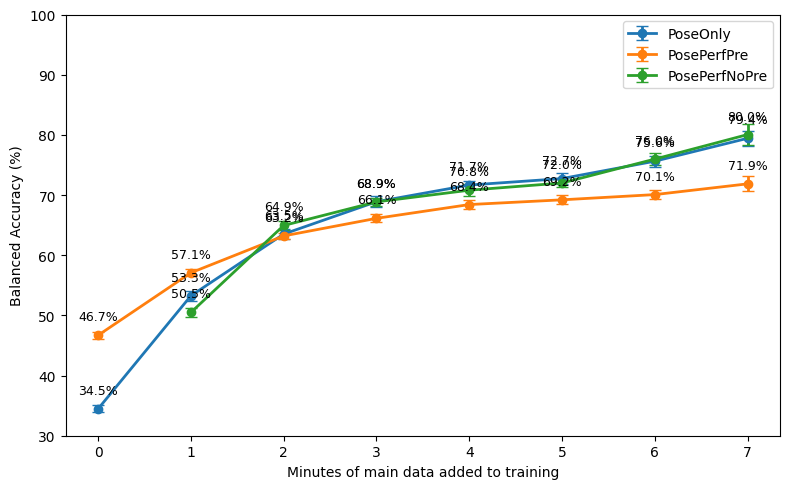

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, cohen_kappa_score

# --- File paths for the data ---
pose_pre_fp         = "data/linear_pose_metrics/baseline_pose_metrics.csv"      # Baseline pose data
performance_pre_fp  = "data/performance/performance_bsl.csv"                    # Baseline performance data
pose_main_fp        = "data/linear_pose_metrics/experimental_pose_metrics.csv"  # Experimental pose data
performance_main_fp = "data/performance/performance_exp.csv"                    # Experimental performance data

# --- Settings for the analysis ---
center_features  = True         # Whether to center features before training
show_progressbar = True         # Show progress bar during training
n_seeds          = 20           # Number of times to repeat training for reliability
cut_minutes      = range(0, 8)  # Try training with 0 to 7 minutes of experimental data
SKIP_EVERY       = 2            # Use every 2nd data window (because the data from before is 50% overlap, we are only training per minute increment here)

# --- Helper functions to load and process data ---
def normalize_window_columns(df):
    # Some CSVs have *_s instead of without suffix -> normalize
    rename_map = {}
    if "window_start_s" in df.columns:
        rename_map["window_start_s"] = "window_start"
    if "window_end_s" in df.columns:
        rename_map["window_end_s"] = "window_end"
    if rename_map:
        df = df.rename(columns=rename_map)
    return df

def load_pose(fp, skip_every):
    df = pd.read_csv(fp)
    df = normalize_window_columns(df)   # <--- added
    if skip_every:
        df = df[df["window_index"] % skip_every == 0]
    df["participant"] = df["participant"].astype(str)
    df["condition"]   = df["condition"].astype(str)
    df["minute"]      = (df["window_start"] / 60).round().astype(int)
    return df.reset_index(drop=True)

def load_perf(fp, skip_every):
    df = pd.read_csv(fp)
    df = normalize_window_columns(df)   # <--- added
    if skip_every:
        df = df[df["window_index"] % skip_every == 0]
    df["participant"] = df["participant"].astype(str)
    df["condition"]   = df["condition"].astype(str)
    df["minute"]      = (df["window_start"] / 60).round().astype(int)
    return df.reset_index(drop=True)


def load_and_merge(pose_fp, perf_fp, skip_every):
    # Load pose and performance data, then merge them by participant, condition, and minute
    pose = load_pose(pose_fp, skip_every).copy()
    perf = load_perf(perf_fp, skip_every).copy()
    perf = perf.drop(columns=["window_start","window_end"], errors="ignore")
    merged = pd.merge(
        pose,
        perf,
        on=["participant","condition","minute"],
        how="inner",
        suffixes=("","_perf")
    )
    return merged

# --- Prepare datasets for training ---
pose_pre_df  = load_pose(pose_pre_fp, SKIP_EVERY)   # Baseline pose data
pose_main_df = load_pose(pose_main_fp, SKIP_EVERY)  # Experimental pose data

# Features and labels for baseline pose
X_pose_pre   = pose_pre_df.drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
y_pose_pre   = pose_pre_df["condition"]

# Merged pose+performance datasets
data_model_2_pre  = load_and_merge(pose_pre_fp,  performance_pre_fp,  SKIP_EVERY)
data_model_2_main = load_and_merge(pose_main_fp, performance_main_fp, SKIP_EVERY)

# --- Model setup ---
models = ["PoseOnly","PosePerfPre","PosePerfNoPre"]   # Three model types to compare
metrics = ["BalancedAcc", "F1", "Kappa"]              # Metrics to track for each model
# Prepare a results dictionary to store scores for each model, minute, and metric
results = {model: {m: {metric: [] for metric in metrics} for m in cut_minutes} for model in models}
seed_iter = tqdm(range(n_seeds), desc="Seeds") if show_progressbar else range(n_seeds)

# --- Training Loop ---
for seed in seed_iter:
    for m in cut_minutes:
        cutoff = m * 60  # Convert minutes to seconds

        # 1) Model 1: Use all baseline pose + growing amount of experimental pose
        mask_train = pose_main_df["window_start"] < cutoff
        mask_test  = pose_main_df["window_start"] >= cutoff
        if mask_test.sum()>0:
            X_tr = pd.concat([X_pose_pre, pose_main_df[mask_train].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])])
            y_tr = pd.concat([y_pose_pre, pose_main_df[mask_train]["condition"]])
            X_te = pose_main_df[mask_test].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
            y_te = pose_main_df[mask_test]["condition"]

            # Build and train the model pipeline (scaling + random forest)
            pipe = Pipeline([
                ("scaler", StandardScaler(with_mean=center_features)),
                ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1))
            ])
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_te)
            # Store results for this run
            results["PoseOnly"][m]["BalancedAcc"].append(balanced_accuracy_score(y_te, y_pred))
            results["PoseOnly"][m]["F1"].append(f1_score(y_te, y_pred, average="weighted"))
            results["PoseOnly"][m]["Kappa"].append(cohen_kappa_score(y_te, y_pred))

        # 2) Model 2: Use all baseline pose+performance + growing experimental pose+performance
        mask_train = data_model_2_main["window_start"] < cutoff
        mask_test  = data_model_2_main["window_start"] >= cutoff
        if mask_test.sum()>0:
            X_tr = pd.concat([
                data_model_2_pre.drop(columns=["participant","condition","window_index","window_start","window_end","minute"]),
                data_model_2_main[mask_train].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
            ])
            y_tr = pd.concat([
                data_model_2_pre["condition"],
                data_model_2_main[mask_train]["condition"]
            ])
            X_te = data_model_2_main[mask_test].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
            y_te = data_model_2_main[mask_test]["condition"]

            pipe = Pipeline([
                ("scaler", StandardScaler(with_mean=center_features)),
                ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1))
            ])
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_te)
            results["PosePerfPre"][m]["BalancedAcc"].append(balanced_accuracy_score(y_te, y_pred))
            results["PosePerfPre"][m]["F1"].append(f1_score(y_te, y_pred, average="weighted"))
            results["PosePerfPre"][m]["Kappa"].append(cohen_kappa_score(y_te, y_pred))

        # 3) Model 3: Only use growing experimental pose (no baseline), start at m>=1
        if m > 0:
            mask_tr = pose_main_df["window_start"] < cutoff
            mask_te = pose_main_df["window_start"] >= cutoff
            if mask_tr.sum() > 0 and mask_te.sum() > 0:
                X_tr = pose_main_df[mask_tr].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
                y_tr = pose_main_df[mask_tr]["condition"]
                X_te = pose_main_df[mask_te].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
                y_te = pose_main_df[mask_te]["condition"]
                pipe = Pipeline([
                    ("scaler", StandardScaler(with_mean=center_features)),
                    ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1))
                ])
                pipe.fit(X_tr, y_tr)
                y_pred = pipe.predict(X_te)
                results["PosePerfNoPre"][m]["BalancedAcc"].append(balanced_accuracy_score(y_te, y_pred))
                results["PosePerfNoPre"][m]["F1"].append(f1_score(y_te, y_pred, average="weighted"))
                results["PosePerfNoPre"][m]["Kappa"].append(cohen_kappa_score(y_te, y_pred))

# --- Helper to format results for display ---
def format_metric(vals):
    # Show mean and standard deviation for each metric
    return f"{np.mean(vals):.3f} ± {np.std(vals, ddof=1):.3f}"

# --- Print results as a table ---
print("\\begin{tabular}{l|" + "c" * len(cut_minutes) + "}")
header = ["Model/Minute"] + [str(m) for m in cut_minutes]
print(" & ".join(header) + " \\\\ \\hline")

for model in models:
    for metric in metrics:
        if model == "PosePerfNoPre":
            row_minutes = cut_minutes[1:]  # skip 0 for this model
        else:
            row_minutes = cut_minutes

        row = [f"{model} ({metric})"]
        for m in row_minutes:
            vals = results[model][m][metric]
            if vals:
                row.append(format_metric(vals))
            else:
                row.append("--")
        print(" & ".join(row) + " \\\\")
print("\\end{tabular}")

# Plotting the learning curves for each model
fig, ax = plt.subplots(figsize=(8,5))
for model in models:
    xs, ys, errs = [], [], []
    for m in cut_minutes:
        if model == "PosePerfNoPre" and m == 0:
            continue
        vals = results[model][m]["BalancedAcc"]
        if not vals:
            continue
        mean = np.mean(vals) * 100  # convert to percentage
        std  = np.std(vals, ddof=1) * 100
        xs.append(m)
        ys.append(mean)
        errs.append(std)

    ax.errorbar(xs, ys, yerr=errs, label=model, marker="o", capsize=4, lw=2)

    # Annotate each point with the value
    for x, y in zip(xs, ys):
        ax.text(x, y + 2, f"{y:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Minutes of main data added to training")
ax.set_ylabel("Balanced Accuracy (%)")
ax.set_xticks(list(cut_minutes))
ax.set_ylim(30, 100)
ax.legend()
plt.tight_layout()

# Save as SVG
plt.savefig("learning_curves.svg", format="svg")

plt.show()


Seeds:   0%|          | 0/20 [00:06<?, ?it/s]

FS[PoseOnly m=0] +center_face_x_mean_abs_vel -> 0.392 (k=1)


Seeds:   0%|          | 0/20 [00:09<?, ?it/s]

FS[PoseOnly m=0] +avg_pupil_x_mean_abs_acc -> 0.414 (k=2)


Seeds:   0%|          | 0/20 [00:12<?, ?it/s]

...

FS[PosePerfNoPre m=7] +center_face_x_mean_abs_vel -> 0.811 (k=13)


Seeds:   0%|          | 0/20 [17:09<?, ?it/s]

FS[PosePerfNoPre m=7] +avg_pupil_y_mean_abs_vel -> 0.817 (k=14)


Seeds: 100%|██████████| 20/20 [18:36<00:00, 55.82s/it]   

\begin{tabular}{l|cccccccc}
Model/Minute & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 \\ \hline
PoseOnly (BalancedAcc) & 0.323 ± 0.004 & 0.353 ± 0.005 & 0.649 ± 0.006 & 0.736 ± 0.007 & 0.783 ± 0.007 & 0.749 ± 0.007 & 0.833 ± 0.008 & 0.861 ± 0.006 \\
PoseOnly (F1) & 0.319 ± 0.004 & 0.353 ± 0.005 & 0.649 ± 0.006 & 0.736 ± 0.007 & 0.783 ± 0.007 & 0.749 ± 0.007 & 0.832 ± 0.008 & 0.860 ± 0.006 \\
PoseOnly (Kappa) & -0.015 ± 0.006 & 0.030 ± 0.008 & 0.475 ± 0.009 & 0.604 ± 0.010 & 0.675 ± 0.010 & 0.623 ± 0.010 & 0.749 ± 0.012 & 0.791 ± 0.009 \\
PosePerfPre (BalancedAcc) & 0.478 ± 0.006 & 0.501 ± 0.004 & 0.543 ± 0.003 & 0.657 ± 0.005 & 0.718 ± 0.006 & 0.709 ± 0.005 & 0.659 ± 0.009 & 0.722 ± 0.012 \\
PosePerfPre (F1) & 0.483 ± 0.006 & 0.503 ± 0.004 & 0.538 ± 0.003 & 0.654 ± 0.005 & 0.717 ± 0.006 & 0.709 ± 0.005 & 0.657 ± 0.008 & 0.720 ± 0.013 \\
PosePerfPre (Kappa) & 0.218 ± 0.009 & 0.253 ± 0.006 & 0.317 ± 0.005 & 0.486 ± 0.007 & 0.577 ± 0.009 & 0.565 ± 0.008 & 0.488 ± 0.013 & 0.583 ± 0.018 \\
PosePerfNoPre

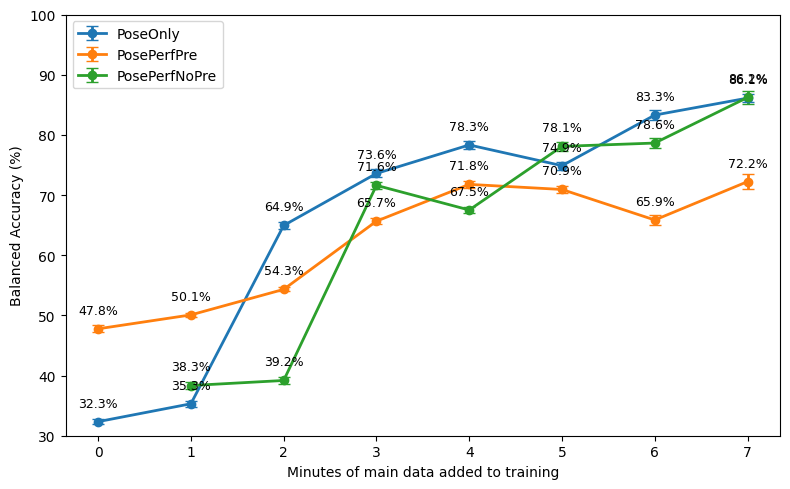

In [12]:
# --- NEW imports for forward selection ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, cohen_kappa_score
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- File paths for the data ---
pose_pre_fp         = "data/linear_pose_metrics/baseline_pose_metrics.csv"
performance_pre_fp  = "data/performance/performance_bsl.csv"
pose_main_fp        = "data/linear_pose_metrics/experimental_pose_metrics.csv"
performance_main_fp = "data/performance/performance_exp.csv"

# --- Settings for the analysis ---
center_features   = True
show_progressbar  = True
n_seeds           = 20
cut_minutes       = range(0, 8)
SKIP_EVERY        = 2

selected_cols_cache = {}

def _make_cv(y, max_folds=5, rng=0):
    y_codes, _ = pd.factorize(y)
    counts = np.bincount(y_codes)
    if len(counts) == 0:
        return StratifiedKFold(n_splits=2, shuffle=True, random_state=rng)
    n_splits = max(2, min(max_folds, int(counts.min())))
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=rng)

from tqdm import tqdm

def forward_select_metrics(
    X, y,
    scoring="balanced_accuracy",
    max_folds=5,
    tol=1e-6,
    show_progress=False,
    tag=None
):
    """
    Greedy forward selection at the metric (column) level.
    Add one feature at a time; stop when CV score doesn't improve.
    Uses RF as evaluator. Returns ordered list of selected columns.
    If show_progress=True, displays a tqdm bar per selection round.
    """
    assert isinstance(X, pd.DataFrame)
    y_codes, _ = pd.factorize(y)
    counts = np.bincount(y_codes)
    if len(counts) == 0 or counts.min() < 2:
        return list(X.columns)  # not enough samples per class → skip FS

    base_est = RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=0, n_jobs=-1)
    cv = _make_cv(y, max_folds=max_folds, rng=0)

    available = list(X.columns)
    selected  = []
    best_score = -np.inf

    round_idx = 0
    while available:
        round_idx += 1
        best_feat, best_try = None, best_score

        # Inner progress bar over candidates this round
        iter_desc = f"FS[{tag}] sel={len(selected)} score={best_score:.3f}" if tag else f"FS sel={len(selected)}"
        iterable = tqdm(available, desc=iter_desc, leave=False) if show_progress else available

        for feat in iterable:
            cols = selected + [feat]
            score = cross_val_score(base_est, X[cols], y, cv=cv, scoring=scoring, n_jobs=-1).mean()
            if score > best_try:
                best_try, best_feat = score, feat

        # stop if no improvement
        if best_feat is None or (best_try - best_score) <= tol:
            break

        # accept the improving feature
        selected.append(best_feat)
        available.remove(best_feat)
        best_score = best_try

        if show_progress:
            # quick one-line update for what was picked
            tqdm.write(f"FS[{tag}] +{best_feat} -> {best_score:.3f} (k={len(selected)})")

    return selected if selected else list(X.columns)

# --- Helper functions to load and process data ---
def normalize_window_columns(df):
    # Some CSVs have *_s instead of without suffix -> normalize
    rename_map = {}
    if "window_start_s" in df.columns:
        rename_map["window_start_s"] = "window_start"
    if "window_end_s" in df.columns:
        rename_map["window_end_s"] = "window_end"
    if rename_map:
        df = df.rename(columns=rename_map)
    return df

def load_pose(fp, skip_every):
    df = pd.read_csv(fp)
    df = normalize_window_columns(df)   # <--- added
    if skip_every:
        df = df[df["window_index"] % skip_every == 0]
    df["participant"] = df["participant"].astype(str)
    df["condition"]   = df["condition"].astype(str)
    df["minute"]      = (df["window_start"] / 60).round().astype(int)
    return df.reset_index(drop=True)

def load_perf(fp, skip_every):
    df = pd.read_csv(fp)
    df = normalize_window_columns(df)   # <--- added
    if skip_every:
        df = df[df["window_index"] % skip_every == 0]
    df["participant"] = df["participant"].astype(str)
    df["condition"]   = df["condition"].astype(str)
    df["minute"]      = (df["window_start"] / 60).round().astype(int)
    return df.reset_index(drop=True)

def load_and_merge(pose_fp, perf_fp, skip_every):
    pose = load_pose(pose_fp, skip_every).copy()
    perf = load_perf(perf_fp, skip_every).copy()
    perf = perf.drop(columns=["window_start","window_end"], errors="ignore")
    merged = pd.merge(
        pose, perf,
        on=["participant","condition","minute"],
        how="inner",
        suffixes=("","_perf")
    )
    return merged

# --- Prepare datasets for training ---
pose_pre_df  = load_pose(pose_pre_fp, SKIP_EVERY)
pose_main_df = load_pose(pose_main_fp, SKIP_EVERY)

X_pose_pre = pose_pre_df.drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
y_pose_pre = pose_pre_df["condition"]

data_model_2_pre  = load_and_merge(pose_pre_fp,  performance_pre_fp,  SKIP_EVERY)
data_model_2_main = load_and_merge(pose_main_fp, performance_main_fp, SKIP_EVERY)

# --- Model setup ---
models  = ["PoseOnly","PosePerfPre","PosePerfNoPre"]
metrics = ["BalancedAcc", "F1", "Kappa"]
results = {model: {m: {metric: [] for metric in metrics} for m in cut_minutes} for model in models}
seed_iter = tqdm(range(n_seeds), desc="Seeds") if show_progressbar else range(n_seeds)

# --- Training Loop ---
for seed in seed_iter:
    for m in cut_minutes:
        cutoff = m * 60  # seconds

        # 1) PoseOnly: baseline pose + growing experimental pose
        mask_train = pose_main_df["window_start"] < cutoff
        mask_test  = pose_main_df["window_start"] >= cutoff
        if mask_test.sum() > 0:
            X_tr = pd.concat([X_pose_pre,
                              pose_main_df[mask_train].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])])
            y_tr = pd.concat([y_pose_pre, pose_main_df[mask_train]["condition"]])
            X_te = pose_main_df[mask_test].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
            y_te = pose_main_df[mask_test]["condition"]

            key = ("PoseOnly", m)
            if key not in selected_cols_cache:
                selected_cols_cache[key] = forward_select_metrics(
                    X_tr, y_tr, scoring="balanced_accuracy", max_folds=5,
                    tol=1e-6, show_progress=True, tag=f"{key[0]} m={m}"
                )
            cols = selected_cols_cache[key]

            pipe = Pipeline([
                ("scaler", StandardScaler(with_mean=center_features)),
                ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                             random_state=seed, n_jobs=-1))
            ])
            pipe.fit(X_tr[cols], y_tr)
            y_pred = pipe.predict(X_te[cols])

            results["PoseOnly"][m]["BalancedAcc"].append(balanced_accuracy_score(y_te, y_pred))
            results["PoseOnly"][m]["F1"].append(f1_score(y_te, y_pred, average="weighted"))
            results["PoseOnly"][m]["Kappa"].append(cohen_kappa_score(y_te, y_pred))

        # 2) PosePerfPre: baseline pose+perf + growing experimental pose+perf
        mask_train = data_model_2_main["window_start"] < cutoff
        mask_test  = data_model_2_main["window_start"] >= cutoff
        if mask_test.sum() > 0:
            X_tr = pd.concat([
                data_model_2_pre.drop(columns=["participant","condition","window_index","window_start","window_end","minute"]),
                data_model_2_main[mask_train].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
            ])
            y_tr = pd.concat([
                data_model_2_pre["condition"],
                data_model_2_main[mask_train]["condition"]
            ])
            X_te = data_model_2_main[mask_test].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
            y_te = data_model_2_main[mask_test]["condition"]

            key = ("PosePerfPre", m)
            if key not in selected_cols_cache:
                selected_cols_cache[key] = forward_select_metrics(
                    X_tr, y_tr, scoring="balanced_accuracy", max_folds=5,
                    tol=1e-6, show_progress=True, tag=f"{key[0]} m={m}"
                )
            cols = selected_cols_cache[key]

            pipe = Pipeline([
                ("scaler", StandardScaler(with_mean=center_features)),
                ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                             random_state=seed, n_jobs=-1))
            ])
            pipe.fit(X_tr[cols], y_tr)
            y_pred = pipe.predict(X_te[cols])

            results["PosePerfPre"][m]["BalancedAcc"].append(balanced_accuracy_score(y_te, y_pred))
            results["PosePerfPre"][m]["F1"].append(f1_score(y_te, y_pred, average="weighted"))
            results["PosePerfPre"][m]["Kappa"].append(cohen_kappa_score(y_te, y_pred))

        # 3) PosePerfNoPre: growing experimental pose only (no baseline), start at m>=1
        if m > 0:
            mask_tr = pose_main_df["window_start"] < cutoff
            mask_te = pose_main_df["window_start"] >= cutoff
            if mask_tr.sum() > 0 and mask_te.sum() > 0:
                X_tr = pose_main_df[mask_tr].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
                y_tr = pose_main_df[mask_tr]["condition"]
                X_te = pose_main_df[mask_te].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
                y_te = pose_main_df[mask_te]["condition"]

                key = ("PosePerfNoPre", m)
                if key not in selected_cols_cache:
                    selected_cols_cache[key] = forward_select_metrics(
                        X_tr, y_tr, scoring="balanced_accuracy", max_folds=5,
                        tol=1e-6, show_progress=True, tag=f"{key[0]} m={m}"
                    )
                cols = selected_cols_cache[key]

                pipe = Pipeline([
                    ("scaler", StandardScaler(with_mean=center_features)),
                    ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                                 random_state=seed, n_jobs=-1))
                ])
                pipe.fit(X_tr[cols], y_tr)
                y_pred = pipe.predict(X_te[cols])

                results["PosePerfNoPre"][m]["BalancedAcc"].append(balanced_accuracy_score(y_te, y_pred))
                results["PosePerfNoPre"][m]["F1"].append(f1_score(y_te, y_pred, average="weighted"))
                results["PosePerfNoPre"][m]["Kappa"].append(cohen_kappa_score(y_te, y_pred))

# --- Helper to format results for display ---
def format_metric(vals):
    return f"{np.mean(vals):.3f} ± {np.std(vals, ddof=1):.3f}"

# --- Print results as a table ---
print("\\begin{tabular}{l|" + "c" * len(cut_minutes) + "}")
header = ["Model/Minute"] + [str(m) for m in cut_minutes]
print(" & ".join(header) + " \\\\ \\hline")

for model in models:
    for metric in metrics:
        row_minutes = cut_minutes[1:] if model == "PosePerfNoPre" else cut_minutes
        row = [f"{model} ({metric})"]
        for m in row_minutes:
            vals = results[model][m][metric]
            row.append(format_metric(vals) if vals else "--")
        print(" & ".join(row) + " \\\\")
print("\\end{tabular}")

# Plot learning curves
fig, ax = plt.subplots(figsize=(8,5))
for model in models:
    xs, ys, errs = [], [], []
    for m in cut_minutes:
        if model == "PosePerfNoPre" and m == 0: 
            continue
        vals = results[model][m]["BalancedAcc"]
        if not vals:
            continue
        mean = np.mean(vals) * 100
        std  = np.std(vals, ddof=1) * 100
        xs.append(m); ys.append(mean); errs.append(std)
    ax.errorbar(xs, ys, yerr=errs, label=model, marker="o", capsize=4, lw=2)
    for x, y in zip(xs, ys):
        ax.text(x, y + 2, f"{y:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Minutes of main data added to training")
ax.set_ylabel("Balanced Accuracy (%)")
ax.set_xticks(list(cut_minutes))
ax.set_ylim(30, 100)
ax.legend()
plt.tight_layout()
plt.savefig("learning_curves.svg", format="svg")
plt.show()


\begin{tabular}{l|cccccccc}
Model/Minute & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 \\ \hline
PoseOnly (BalancedAcc) & 0.345 ± 0.006 & 0.533 ± 0.008 & 0.649 ± 0.006 & 0.736 ± 0.007 & 0.783 ± 0.007 & 0.749 ± 0.007 & 0.833 ± 0.008 & 0.861 ± 0.006 \\
PoseOnly (F1) & 0.340 ± 0.006 & 0.529 ± 0.008 & 0.649 ± 0.006 & 0.736 ± 0.007 & 0.783 ± 0.007 & 0.749 ± 0.007 & 0.832 ± 0.008 & 0.860 ± 0.006 \\
PoseOnly (Kappa) & 0.017 ± 0.008 & 0.300 ± 0.012 & 0.475 ± 0.009 & 0.604 ± 0.010 & 0.675 ± 0.010 & 0.623 ± 0.010 & 0.749 ± 0.012 & 0.791 ± 0.009 \\
PosePerfPre (BalancedAcc) & 0.478 ± 0.006 & 0.571 ± 0.006 & 0.632 ± 0.005 & 0.661 ± 0.007 & 0.718 ± 0.006 & 0.709 ± 0.005 & 0.701 ± 0.008 & 0.722 ± 0.012 \\
PosePerfPre (F1) & 0.483 ± 0.006 & 0.557 ± 0.008 & 0.626 ± 0.005 & 0.659 ± 0.007 & 0.717 ± 0.006 & 0.709 ± 0.005 & 0.698 ± 0.008 & 0.720 ± 0.013 \\
PosePerfPre (Kappa) & 0.218 ± 0.009 & 0.359 ± 0.009 & 0.451 ± 0.007 & 0.494 ± 0.010 & 0.577 ± 0.009 & 0.565 ± 0.008 & 0.551 ± 0.011 & 0.583 ± 0.018 \\
PosePerfNoPre 

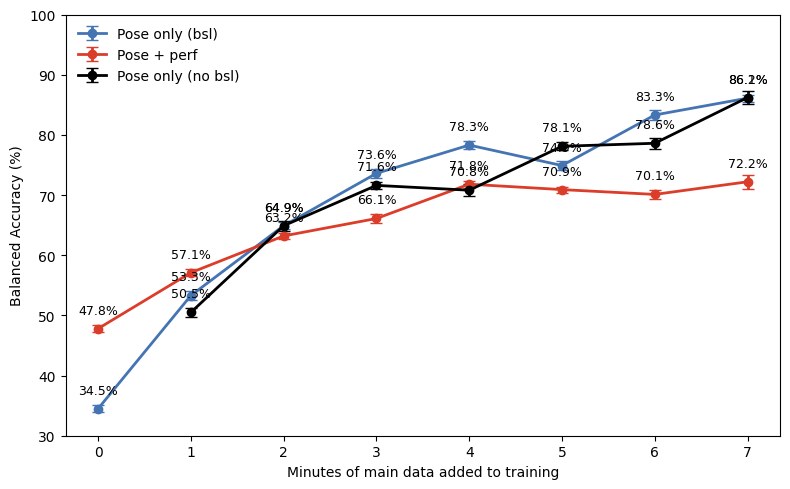

In [14]:
# In the previous cells, we trained models using no feature selection and forward 
# selection at the metric level. Now we pick whichever was best for each minute. 
import re
import numpy as np
# --------- parsing helpers ---------
_row_re = re.compile(r'^\s*([^&]+?)\s*&(.+?)\\\\')       # leading cell + rest until '\\'
_cell_re = re.compile(r'([0-9]*\.?[0-9]+)\s*±\s*([0-9]*\.?[0-9]+)')

def _clean(s): return s.strip().replace('\\', '')

def parse_minutes(header_line):
    # header like: Model/Minute & 0 & 1 & ... & 7 \\ \hline
    parts = [p.strip() for p in header_line.split('&')]
    mins = []
    for p in parts[1:]:
        p = p.replace('\\hline', '').replace('\\\\', '').strip()
        if p == '' or p.lower().startswith('model'): 
            continue
        try:
            mins.append(int(p))
        except ValueError:
            pass
    return mins

def parse_latex_table(latex_str):
    """
    Returns:
      minutes: list[int]
      results: dict[model][metric] -> list of (mean,std) aligned to minutes
    """
    lines = [ln for ln in latex_str.splitlines() if ln.strip()]
    # find header with minutes
    header_idx = None
    for i, ln in enumerate(lines):
        if 'Model/Minute' in ln:
            header_idx = i
            break
    if header_idx is None:
        raise ValueError("Couldn't find header with 'Model/Minute'.")

    minutes = parse_minutes(lines[header_idx])
    nM = len(minutes)
    results = {}

    for ln in lines[header_idx+1:]:
        if ln.strip().startswith('\\hline') or ln.strip().startswith('\\end{tabular}'):
            continue
        m = _row_re.search(ln)
        if not m:
            continue
        head, rest = m.groups()
        head = _clean(head)
        # e.g., "PoseOnly (BalancedAcc)"
        if '(' in head and head.endswith(')'):
            model = head[:head.rfind('(')].strip()
            metric = head[head.rfind('(')+1:-1].strip()
        else:
            # skip malformed lines
            continue

        # split cells
        cells = [c.strip() for c in rest.split('&')]
        vals = []
        for c in cells:
            c = c.replace('\\', '').replace('\\hline','').strip()
            if c in ('--', ''):
                vals.append(None)
                continue
            m2 = _cell_re.search(c)
            if not m2:
                vals.append(None)
            else:
                mu, sd = float(m2.group(1)), float(m2.group(2))
                vals.append((mu, sd))

        # Align to minutes. Common special-case: PosePerfNoPre has no m=0.
        aligned = [None]*nM
        if len(vals) == nM:
            start = 0
        elif len(vals) == nM - 1 and model == 'PosePerfNoPre':
            start = 1  # assume starts at minute 1
        else:
            # Try best-effort: left-align
            start = 0

        for i, v in enumerate(vals):
            idx = start + i
            if 0 <= idx < nM:
                aligned[idx] = v

        results.setdefault(model, {})[metric] = aligned

    return minutes, results

# --------- merge by taking the higher mean ---------
def merge_best(res_a, res_b):
    merged = {}
    for model in res_a.keys() | res_b.keys():
        merged[model] = {}
        metrics = (res_a.get(model, {}) .keys()) | (res_b.get(model, {}) .keys())
        for metric in metrics:
            A = res_a.get(model, {}).get(metric, [])
            B = res_b.get(model, {}).get(metric, [])
            L = max(len(A), len(B))
            out = []
            for i in range(L):
                a = A[i] if i < len(A) else None
                b = B[i] if i < len(B) else None
                if a is None and b is None:
                    out.append(None)
                elif a is None:
                    out.append(b)
                elif b is None:
                    out.append(a)
                else:
                    out.append(a if a[0] >= b[0] else b)
            merged[model][metric] = out
    return merged

# --------- render back to LaTeX ---------
def to_latex(minutes, results):
    models_order = ['PoseOnly','PosePerfPre','PosePerfNoPre']
    metrics_order = ['BalancedAcc','F1','Kappa']
    header = "\\begin{tabular}{l|" + "c"*len(minutes) + "}\n"
    header += "Model/Minute & " + " & ".join(str(m) for m in minutes) + " \\\\ \\hline\n"
    rows = []
    for model in models_order:
        if model not in results: 
            continue
        for metric in metrics_order:
            row = [f"{model} ({metric})"]
            vals = results[model].get(metric, [None]*len(minutes))
            for v in vals:
                if v is None:
                    row.append("--")
                else:
                    row.append(f"{v[0]:.3f} ± {v[1]:.3f}")
            rows.append(" & ".join(row) + " \\\\")
    return header + "\n".join(rows) + "\n\\end{tabular}"

# ===================== USAGE =====================
# 1) Paste your two LaTeX tables here
latex_no_fs = r"""
\begin{tabular}{l|cccccccc}
Model/Minute & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 \\ \hline
PoseOnly (BalancedAcc) & 0.345 ± 0.006 & 0.533 ± 0.008 & 0.635 ± 0.008 & 0.689 ± 0.009 & 0.717 ± 0.007 & 0.727 ± 0.009 & 0.756 ± 0.009 & 0.794 ± 0.013 \\
PoseOnly (F1) & 0.340 ± 0.006 & 0.529 ± 0.008 & 0.635 ± 0.008 & 0.689 ± 0.009 & 0.717 ± 0.007 & 0.727 ± 0.009 & 0.756 ± 0.009 & 0.793 ± 0.013 \\
PoseOnly (Kappa) & 0.017 ± 0.008 & 0.300 ± 0.012 & 0.453 ± 0.012 & 0.534 ± 0.013 & 0.575 ± 0.010 & 0.591 ± 0.014 & 0.634 ± 0.013 & 0.691 ± 0.020 \\
PosePerfPre (BalancedAcc) & 0.467 ± 0.006 & 0.571 ± 0.006 & 0.632 ± 0.005 & 0.661 ± 0.007 & 0.684 ± 0.007 & 0.692 ± 0.007 & 0.701 ± 0.008 & 0.719 ± 0.012 \\
PosePerfPre (F1) & 0.463 ± 0.006 & 0.557 ± 0.008 & 0.626 ± 0.005 & 0.659 ± 0.007 & 0.683 ± 0.007 & 0.690 ± 0.008 & 0.698 ± 0.008 & 0.717 ± 0.013 \\
PosePerfPre (Kappa) & 0.203 ± 0.009 & 0.359 ± 0.009 & 0.451 ± 0.007 & 0.494 ± 0.010 & 0.527 ± 0.010 & 0.538 ± 0.011 & 0.551 ± 0.011 & 0.578 ± 0.019 \\
PosePerfNoPre (BalancedAcc) & 0.505 ± 0.007 & 0.649 ± 0.008 & 0.689 ± 0.006 & 0.708 ± 0.010 & 0.720 ± 0.007 & 0.760 ± 0.010 & 0.800 ± 0.017 \\
PosePerfNoPre (F1) & 0.504 ± 0.007 & 0.649 ± 0.008 & 0.689 ± 0.006 & 0.708 ± 0.010 & 0.720 ± 0.007 & 0.759 ± 0.010 & 0.798 ± 0.017 \\
PosePerfNoPre (Kappa) & 0.258 ± 0.011 & 0.474 ± 0.011 & 0.533 ± 0.009 & 0.562 ± 0.014 & 0.580 ± 0.011 & 0.640 ± 0.015 & 0.700 ± 0.025 \\
\end{tabular}
"""

latex_fs = r"""
\begin{tabular}{l|cccccccc}
Model/Minute & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 \\ \hline
PoseOnly (BalancedAcc) & 0.323 ± 0.004 & 0.353 ± 0.005 & 0.649 ± 0.006 & 0.736 ± 0.007 & 0.783 ± 0.007 & 0.749 ± 0.007 & 0.833 ± 0.008 & 0.861 ± 0.006 \\
PoseOnly (F1) & 0.319 ± 0.004 & 0.353 ± 0.005 & 0.649 ± 0.006 & 0.736 ± 0.007 & 0.783 ± 0.007 & 0.749 ± 0.007 & 0.832 ± 0.008 & 0.860 ± 0.006 \\
PoseOnly (Kappa) & -0.015 ± 0.006 & 0.030 ± 0.008 & 0.475 ± 0.009 & 0.604 ± 0.010 & 0.675 ± 0.010 & 0.623 ± 0.010 & 0.749 ± 0.012 & 0.791 ± 0.009 \\
PosePerfPre (BalancedAcc) & 0.478 ± 0.006 & 0.501 ± 0.004 & 0.543 ± 0.003 & 0.657 ± 0.005 & 0.718 ± 0.006 & 0.709 ± 0.005 & 0.659 ± 0.009 & 0.722 ± 0.012 \\
PosePerfPre (F1) & 0.483 ± 0.006 & 0.503 ± 0.004 & 0.538 ± 0.003 & 0.654 ± 0.005 & 0.717 ± 0.006 & 0.709 ± 0.005 & 0.657 ± 0.008 & 0.720 ± 0.013 \\
PosePerfPre (Kappa) & 0.218 ± 0.009 & 0.253 ± 0.006 & 0.317 ± 0.005 & 0.486 ± 0.007 & 0.577 ± 0.009 & 0.565 ± 0.008 & 0.488 ± 0.013 & 0.583 ± 0.018 \\
PosePerfNoPre (BalancedAcc) & 0.383 ± 0.006 & 0.392 ± 0.007 & 0.716 ± 0.006 & 0.675 ± 0.005 & 0.781 ± 0.007 & 0.786 ± 0.009 & 0.862 ± 0.011 \\
PosePerfNoPre (F1) & 0.383 ± 0.006 & 0.392 ± 0.007 & 0.716 ± 0.006 & 0.675 ± 0.005 & 0.780 ± 0.007 & 0.786 ± 0.009 & 0.862 ± 0.011 \\
PosePerfNoPre (Kappa) & 0.075 ± 0.008 & 0.088 ± 0.010 & 0.574 ± 0.008 & 0.513 ± 0.008 & 0.670 ± 0.010 & 0.679 ± 0.014 & 0.793 ± 0.017 \\
\end{tabular}
"""

# 2) Parse both
mins_a, res_a = parse_latex_table(latex_no_fs)
mins_b, res_b = parse_latex_table(latex_fs) if latex_fs.strip() else (mins_a, {})

# Sanity: minutes must match
if mins_a != mins_b:
    raise ValueError(f"Minute grids differ: {mins_a} vs {mins_b}")

# 3) Merge by keeping the higher mean
res_best = merge_best(res_a, res_b)

# 4) Emit merged LaTeX
latex_merged = to_latex(mins_a, res_best)
print(latex_merged)

# 5) Example: extract one series for plotting with error bars
def get_series(results, model, metric):
    vals = results[model][metric]
    means = [v[0] if v else np.nan for v in vals]
    stds  = [v[1] if v else np.nan for v in vals]
    return np.array(means), np.array(stds)

means_bal, stds_bal = get_series(res_best, "PosePerfNoPre", "BalancedAcc")
import matplotlib.pyplot as plt

# --- color + label mapping ---
model_labels = {
    "PosePerfNoPre": "Pose only (no bsl)",  # growing experimental only
    "PosePerfPre":   "Pose + perf",         # baseline pose+perf + growing pose+perf
    "PoseOnly":      "Pose only (bsl)",     # baseline pose + growing pose
}
model_colors = {
    "PosePerfNoPre": "#000000",
    "PosePerfPre":   "#dc3d2a",
    "PoseOnly":      "#4574b3",
}

def series(results, model, metric="BalancedAcc"):
    vals = results[model][metric]
    means = np.array([v[0] if v else np.nan for v in vals]) * 100.0
    stds  = np.array([v[1] if v else np.nan for v in vals]) * 100.0
    mins  = np.array(mins_a, dtype=float)
    # mask missing
    m = ~np.isnan(means)
    return mins[m], means[m], stds[m]

fig, ax = plt.subplots(figsize=(8, 5))

order = ["PoseOnly", "PosePerfPre", "PosePerfNoPre"]  # plot order (adjust if you like)
for model in order:
    xs, ys, es = series(res_best, model, metric="BalancedAcc")
    ax.errorbar(
        xs, ys, yerr=es,
        label=model_labels[model],
        marker="o", lw=2, capsize=4,
        color=model_colors[model]
    )
    # annotate means
    for x, y in zip(xs, ys):
        ax.text(x, y + 2, f"{y:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Minutes of main data added to training")
ax.set_ylabel("Balanced Accuracy (%)")
ax.set_xticks(mins_a)
ax.set_ylim(30, 100)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("figs/figure_5_model_acc_learning_curves/merged_best_learning_curves.svg")
plt.show()
